# Proyecto Integrador de Optimización — Cacao 2025

**Módulo 5: Optimización Matemática y Métodos Computacionales**  
**Maestría en Estadística con mención en Ciencia de Datos e Inteligencia Artificial — UCE**  

> **Tema:** Optimización de la asignación muestral provincial para mejorar la precisión de la estimación del rendimiento de cacao en Ecuador, con aplicación al Operativo de Rendimientos Objetivos (ORO) Cacao 2025.

**Nota:** El paquete reproducible incluye solamente un extracto no identificable de la base original (`provincia`, `RN`, `estado` y un índice anónimo).

# 1. Resumen



El Operativo de Rendimientos Objetivos (ORO) Cacao 2025 planificó **938 UPA** distribuidas entre 21 provincias. La base final disponible contiene **962 registros**, de los cuales **957** corresponden a operativos completos con un valor válido de rendimiento neto $RN$. Estas tres cifras cumplen funciones distintas: 938 es el tamaño planificado que se conserva como esfuerzo fijo de comparación; 962 es el número de registros finalmente disponibles; y 957 es el subconjunto utilizado para estimar la variabilidad provincial $S_h^{2025}$.

La decisión real es un número de UPA, por lo que

$$
n_h\in\mathbb Z_+.
$$

Para analizarlo rigurosamente se estudia primero su relajación continua convexa, que permite utilizar CVXPY, derivar KKT/duales y obtener una cota inferior. La relajación se verifica analíticamente mediante la asignación de Neyman $n_h\propto W_hS_h$ y, cuando existen cotas activas, mediante su versión acotada obtenida con KKT y bisección. La solución final entera se obtiene con un algoritmo exacto de ganancias marginales decrecientes.

El ejercicio es retrospectivo: $S_h^{2025}$ se estima con datos levantados durante 2025 y, por tanto, no habría estado disponible al momento de diseñar ese mismo operativo. En este proyecto se usa como un benchmark ex post (punto de referencia para evaluar la eficiencia de otras asignaciones muestrales) para cuantificar qué tan eficiente habría sido una redistribución con la variabilidad finalmente observada. Para planificación futura se necesitaría usar variabilidad histórica, una muestra piloto o una actualización previa.

La comparación se completa con Differential Evolution sobre decisiones enteras, bootstrap estratificado, análisis de complejidad y condicionamiento, sensibilidad al tamaño total $T$ y a la cobertura mínima $n_{\min}$, además de una evaluación explícita del costo de integralidad sobre la varianza mínima.

# 2. Problema de decisión y pertinencia

## 2.1 Contexto

El ORO Cacao estima el rendimiento neto del cultivo mediante mediciones realizadas en UPA de provincias productoras. La metodología 2025 calculó tamaños de muestra provinciales mediante Muestreo Aleatorio Simple para variable cuantitativa, con parámetros diferenciados de confianza, error y variabilidad histórica.

El proyecto no afirma que el diseño institucional sea incorrecto. Formula una pregunta alternativa de optimización: si el esfuerzo nacional se fija en las 938 UPA planificadas, ¿qué distribución conjunta minimiza la varianza de la estimación nacional?

## 2.2 Uso de la información

| Cantidad | Significado | Uso en el proyecto |
|---:|---|---|
| **938** | UPA planificadas en la metodología 2025 | Se fija como presupuesto muestral $T$ y baseline comparable |
| **962** | registros finalmente disponibles en la base 2025 | Evidencia del levantamiento final; **no** se usa como $T$ |
| **957** | registros completos con $RN$ válido | Se usan para estimar $S_h^{2025}$ y realizar bootstrap |

La información disponible no establece en este proyecto la causa específica de la diferencia entre 938 y 962; por ello no se atribuye a reemplazos, sobrecobertura u otra razón sin evidencia adicional.

## 2.3 Pregunta de optimización

¿Cómo distribuir un total fijo de 938 UPA entre 21 provincias productoras de cacao para minimizar la varianza estimada del rendimiento nacional, manteniendo cobertura provincial y sin exceder la población disponible?

## 2.4 Uso de los resultados

El resultado puede utilizarse como benchmark cuantitativo, es decir, un punto de referencia para evaluar la eficiencia de otras asignaciones muestrales, por el equipo que planifica operativos estadísticos agrícolas para comparar una asignación institucional con una alternativa optimizada.

## 2.5 Relevancia

Con recursos limitados, dos asignaciones con el mismo total de 938 UPA pueden producir distinta precisión nacional. La optimización cuantifica ese costo de oportunidad.

## 2.6 Alcance

**Incluye:** asignación provincial entera, precisión nacional, cobertura mínima, población provincial, incertidumbre de $S_h$, comparación con el diseño oficial, integralidad, heurística y sensibilidad.

**No incluye:** costos de movilización, rutas de campo, disponibilidad de técnicos, selección de UPA individuales ni causalidad productiva.

## 2.7 Supuestos

1. Las provincias se tratan como estratos o dominios de planificación.
2. Dentro de cada provincia se supone Muestreo Aleatorio Simple.
3. $N_h$ se considera fijo en el horizonte del ejercicio.
4. $S_h^{2025}$ se usa como estimación retrospectiva de la variabilidad observada.
5. Cada UPA cuenta como una unidad de esfuerzo; no se modelan costos diferenciales por provincia.
6. Las varianzas entre estratos se agregan bajo el estimador estratificado usual.

## 2.8 Carácter retrospectivo y uso futuro

Usar $S_h^{2025}$ para evaluar cómo habría convenido distribuir la muestra de 2025 implica utilizar información conocida después del levantamiento. Por eso la solución no se presenta como una decisión que hubiera podido implementarse sin información adicional.

Para un operativo futuro, el mismo procedimiento puede aplicarse usando:

- $S_h$ del año anterior
- Una estimación obtenida de una muestra piloto
- Una combinación histórica robusta
- Una actualización secuencial antes del levantamiento principal

## 2.9 Baseline

El baseline es la asignación oficial planificada para 2025, con total de 938 UPA. Se evalúa con la misma función objetivo y los $S_h^{2025}$, de modo que la comparación sea retrospectiva y se concentre en la asignación.

# 3. Datos, parámetros y variables de decisión

| Símbolo | Descripción | Tipo | Dimensión | Unidad | Fuente |
|---|---|---|---|---|---|
| $n_h$ | UPA asignadas a provincia $h$ | **decisión entera** | $H=21$ | UPA | modelo |
| $N_h$ | población estimada de UPA | parámetro | $H$ | UPA | metodología 2025 |
| $N$ | población nacional estimada | parámetro | 1 | UPA | metodología 2025 |
| $W_h=N_h/N$ | peso poblacional | parámetro | $H$ | adimensional | calculado |
| $S_h^{2025}$ | desviación estándar de $RN$ observada en 2025 | parámetro estimado | $H$ | t/ha | base 2025 |
| $S_h^{2024}$ | desviación estándar histórica usada en el diseño 2025 | parámetro histórico | $H$ | t/ha | metodología 2025 |
| $a_h=W_h^2S_h^2$ | coeficiente de varianza | parámetro | $H$ | (t/ha)$^2$ | calculado |
| $T$ | tamaño total a asignar | parámetro | 1 | UPA | $T=938$, diseño 2025 |
| $\ell_h$ | cobertura mínima | parámetro | $H$ | UPA | supuesto base / sensibilidad |
| $u_h=N_h$ | máximo disponible | parámetro | $H$ | UPA | metodología 2025 |


- **Dato observado:** $RN_{hi}$, provincia y estado del operativo.
- **Parámetro estimado ex post:** $S_h^{2025}$.
- **Parámetro histórico/prospectivo:** $S_h^{2024}$.
- **Parámetro de marco:** $N_h$.
- **Variable de decisión:** $n_h\in\mathbb Z_+$.

La variable `RN` corresponde al rendimiento neto total en t/ha.

Notar que, el modelo usa los 957 registros completos para estimar $S_h^{2025}$, pero conserva $T=938$ porque el objetivo es comparar la asignación optimizada con el mismo esfuerzo muestral planificado.

# 4. Formulación matemática — Criterio 1

Sea $h=1,\ldots,H$, con $H=21$. La varianza aproximada del estimador estratificado de la media nacional con corrección por población finita es:

$$
V(\mathbf n)=
\sum_{h=1}^{H}
W_h^2 S_h^2
\left(
\frac{1}{n_h}-\frac{1}{N_h}
\right).
$$
donde,

- $V(n)):$ Varianza de la estimación nacional
- $W_h$: Peso poblacional de la provincia
- $S_h^2$: Varianza provincial del rendimiento
- $n_h$: UPA que decidimos muestrear en la provincia h
- $N_h$: Número total estimado de UPA de cacao en la provincia h


## 4.1 Problema

Como $n_h$ representa número de UPA, la formulación que corresponde a la decisión real es:

$$
\boxed{
\begin{aligned}
\min_{\mathbf n}\quad &
\sum_{h=1}^{H}
W_h^2S_h^2
\left(
\frac{1}{n_h}-\frac{1}{N_h}
\right)\\
\text{sujeto a}\quad &
\sum_{h=1}^{H}n_h=T,\\
&
\ell_h\le n_h\le N_h,
\qquad h=1,\ldots,H,\\
&
n_h\in\mathbb Z_+.
\end{aligned}
}
$$

Para el escenario base:

$$
T=938,
\qquad
\ell_h=9.
$$

## 4.2 Relajación continua

Para estudiar convexidad, KKT, dualidad y obtener una cota inferior del problema entero, se considera:

$$
n_h\in\mathbb R_{++}.
$$

La relajación es:

$$
\boxed{
\begin{aligned}
\min_{\mathbf n\in\mathbb R_{++}^H}\quad &
V(\mathbf n)\\
\text{sujeto a}\quad &
\sum_h n_h=938,\\
&
\ell_h\le n_h\le N_h.
\end{aligned}
}
$$

Como el conjunto entero es un subconjunto del conjunto relajado:

$$
V(\mathbf n_{\text{rel}}^\star)
\le
V(\mathbf n_{\mathbb Z}^\star).
$$

Por ello, el óptimo relajado constituye una cota inferior para la varianza mínima alcanzable con tamaños enteros.

## 4.3 Interpretación

La parte variable:

$$
W_h^2S_h^2\frac{1}{n_h}
$$

disminuye al aumentar la muestra del estrato. El término:

$$
-W_h^2S_h^2\frac{1}{N_h}
$$

es constante respecto de la decisión y representa la corrección por población finita.

## 4.4 Unidad de las restricciones

| Restricción | Unidad | Origen / justificación |
|---|---|---|
| $\sum_h n_h=938$ | UPA | tamaño total planificado en la metodología 2025; permite comparar con igual esfuerzo |
| $n_h\ge \ell_h$ | UPA | cobertura mínima; $\ell_h=9$ es supuesto base sometido a sensibilidad |
| $n_h\le N_h$ | UPA | no puede seleccionarse más UPA que la población estimada del estrato |
| $n_h\in\mathbb Z_+$ | UPA | una muestra real contiene un número entero de unidades |

La función objetivo tiene unidades de $(\text{t/ha})^2$.

# 5. Análisis de convexidad / no convexidad — Criterio 1

## 5.1 Problema final

El problema con:

$$
n_h\in\mathbb Z_+
$$

es discreto. Por tanto, no es un problema convexo continuo en el sentido estándar, aunque su función objetivo provenga de una función convexa.

## 5.2 Relajación convexa

Se define:

$$
a_h=W_h^2S_h^2>0.
$$

En la relajación:

$$
f(\mathbf n)=\sum_{h=1}^{H}\frac{a_h}{n_h},
\qquad n_h>0.
$$

Para cada componente:

$$
f_h'(n_h)=-\frac{a_h}{n_h^2},
$$

$$
f_h''(n_h)=\frac{2a_h}{n_h^3}>0.
$$

El Hessiano es:

$$
\nabla^2 f(\mathbf n)=
\operatorname{diag}
\left(
\frac{2a_1}{n_1^3},
\ldots,
\frac{2a_H}{n_H^3}
\right)>0.
$$

Las restricciones de la relajación son afines, por lo que el conjunto factible es convexo. Además:

- Existe un punto factible
- El conjunto es cerrado y acotado
- La función es estrictamente convexa
- La solución relajada es única y global.

## 5.3 Estructura del problema

Para valores enteros, la reducción de varianza obtenida al incrementar una UPA en el estrato $h$ es:

$$
\Delta_h(k)
=
\frac{a_h}{k}
-
\frac{a_h}{k+1}
=
\frac{a_h}{k(k+1)}.
$$

Como $\Delta_h(k)$ disminuye al crecer $k$, existe una estructura de beneficios marginales decrecientes. Esto permite resolver exactamente la asignación entera agregando cada UPA restante al estrato con mayor beneficio marginal disponible.

En consecuencia:

- CVXPY/KKT/Neyman se utilizan para la relajación convexa
- El algoritmo marginal entero produce la decisión final

# 6. Configuración computacional y reproducibilidad

A continuación se tiene:

1. Fijación fr la semilla
2. Instala dependencias únicamente si faltan
3. Reporta versiones
4. Define una escala numérica para el objetivo

Se considera que, la multiplicación del objetivo por una constante positiva no cambia el minimizador. Se usa `OBJ_SCALE = 1e6` dentro del solver para evitar trabajar con valores del orden de $10^{-5}$.

In [3]:
import sys, subprocess, importlib.util, platform, time, warnings
from pathlib import Path

def asegurar_paquete(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        paquete = pip_name or import_name
        print(f"Instalando dependencia faltante: {paquete}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])

for imp, pipn in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
    ("cvxpy", "cvxpy"),
]:
    asegurar_paquete(imp, pipn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import scipy.optimize as spo
from scipy.stats import norm
import cvxpy as cp
from IPython.display import display

SEED = 2026
rng = np.random.default_rng(SEED)
OBJ_SCALE = 1e6

# Tolerancias explícitas para reproducibilidad numérica.
CLARABEL_OPTS = {
    "tol_gap_abs": 1e-9,
    "tol_gap_rel": 1e-9,
    "tol_feas": 1e-9,
    "max_iter": 200,
}
SCS_OPTS = {
    "eps": 1e-7,
    "max_iters": 50000,
}

print("Python:", sys.version.split()[0])
print("Plataforma:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("CVXPY:", cp.__version__)
print("Solvers instalados:", cp.installed_solvers())

Python: 3.13.15
Plataforma: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.1.3
Pandas: 2.2.3
SciPy: 1.16.3
CVXPY: 1.6.7
Solvers instalados: ['CLARABEL', 'CVXOPT', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


# 7. Datos y control de calidad

## Información

- Base institucional Operativos de Rendimientos Objetivos Cacao 2025.
- Diccionario de variables de la base.
- Metodología de muestreo para ORO Cacao 2025.

## Variables utilizadas

- `provincia`
- `RN`: rendimiento neto anual (t/ha)
- `estado`: completo/incompleto

No se utilizan identificadores personales.

## Criterios dconsiderados

1. Se conservan únicamente operativos con `estado = completo`.
2. Se requiere `RN` no faltante.
3. No se imputan rendimientos porque los faltantes corresponden a operativos incompletos.
4. No se eliminan valores extremos únicamente por una regla automática IQR, pues ello modificaría directamente $S_h$.
5. No se normaliza $RN$, ya que la función objetivo conserva la interpretación en unidades de varianza.

Notar que, la base final contiene 962 registros, mientras que la metodología planificó 938 UPA. Este prroyecto no sustituye $T=938$ por 962: mantiene 938 como tamaño de comparación y usa los registros completos disponibles únicamente para estimar $S_h^{2025}$.

Además, $S_h^{2025}$ convierte el ejercicio principal en un análisis retrospectivo. La Sección 16 compara también $S_h^{2024}$ y $S_h^{2025}$ para estudiar cómo cambiaría la decisión al utilizar información disponible antes o después del operativo.

In [4]:
# ---------- Localización de archivos ----------
def buscar_archivo(nombre):
    candidatos = [
        Path(nombre),
        Path.cwd() / nombre,
        Path("/content") / nombre,
        Path("/mnt/data") / nombre,
    ]
    for p in candidatos:
        if p.exists():
            return p
    return None


def subir_archivos_colab_si_faltan(nombres):
    """En Colab, permite seleccionar archivos si no están en /content."""
    faltantes = [n for n in nombres if buscar_archivo(n) is None]
    if not faltantes:
        return
    try:
        from google.colab import files
        print("Faltan archivos requeridos:", ", ".join(faltantes))
        print("Seleccione los archivos solicitados en el cuadro de carga.")
        files.upload()
    except ImportError:
        # Fuera de Colab no se solicita interacción.
        pass

subir_archivos_colab_si_faltan([
    "datos_cacao_proyecto.csv",
    "parametros_muestreo_cacao_2025.csv",
])


path_datos = buscar_archivo("datos_cacao_proyecto.csv")
path_params = buscar_archivo("parametros_muestreo_cacao_2025.csv")

# Fallback al Excel original si el extracto no está presente.
if path_datos is not None:
    datos = pd.read_csv(path_datos)
    fuente_datos = str(path_datos)
else:
    # El fallback solo se usa si se ejecuta el notebook junto al Excel original.
    asegurar_paquete("openpyxl", "openpyxl")
    candidatos_xlsx = (
        list(Path.cwd().glob("*Cacao*2025*.xlsx")) +
        list(Path("/content").glob("*Cacao*2025*.xlsx")) +
        list(Path("/mnt/data").glob("*Cacao*2025*.xlsx"))
    )
    if not candidatos_xlsx:
        raise FileNotFoundError(
            "No se encontró datos_cacao_proyecto.csv ni el Excel original. "
            "Coloque los archivos del paquete en la misma carpeta del notebook."
        )
    xlsx = candidatos_xlsx[0]
    datos = pd.read_excel(
        xlsx,
        sheet_name="Base_preprocesada_Cacao",
        usecols=["provincia", "RN", "estado"]
    )
    datos.insert(0, "fila_anonima", np.arange(1, len(datos)+1))
    fuente_datos = str(xlsx)

if path_params is None:
    raise FileNotFoundError(
        "No se encontró parametros_muestreo_cacao_2025.csv. "
        "Coloque el archivo incluido en el paquete junto al notebook."
    )

marco = pd.read_csv(path_params)

# ---------- Normalización mínima ----------
for df in (datos, marco):
    df["provincia"] = df["provincia"].astype(str).str.strip().str.upper()

datos["estado"] = datos["estado"].astype(str).str.strip().str.lower()
datos["RN"] = pd.to_numeric(datos["RN"], errors="coerce")

# ---------- Control de calidad ----------
n_total_base = len(datos)
n_completos = int((datos["estado"] == "completo").sum())
n_rn_validos = int(datos["RN"].notna().sum())
n_provincias = datos["provincia"].nunique()

completos = datos.loc[
    (datos["estado"] == "completo") & datos["RN"].notna(),
    ["fila_anonima", "provincia", "RN"]
].copy()

resumen_calidad = pd.DataFrame({
    "indicador": [
        "Registros totales",
        "Operativos completos",
        "RN válidos",
        "Registros usados",
        "Provincias"
    ],
    "valor": [
        n_total_base,
        n_completos,
        n_rn_validos,
        len(completos),
        n_provincias
    ]
})
display(resumen_calidad)

# Distinción solicitada por el profesor: planificado vs. finalmente disponible.
comparacion_tamanos = pd.DataFrame({
    "concepto": [
        "UPA planificadas (metodología 2025)",
        "Registros finales disponibles en la base",
        "Registros completos con RN usados para estimar S_2025",
    ],
    "cantidad": [
        int(marco["n_oficial"].sum()),
        n_total_base,
        len(completos),
    ],
    "uso": [
        "Presupuesto T y baseline",
        "Descripción del levantamiento final; no se usa como T",
        "Estimación de S_h^2025 y bootstrap",
    ],
})
display(comparacion_tamanos)

# IQR global como diagnóstico descriptivo, sin eliminar observaciones.
q1, q3 = completos["RN"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
n_atipicos_iqr = int(((completos["RN"] < lim_inf) | (completos["RN"] > lim_sup)).sum())

print(f"Fuente cargada: {fuente_datos}")
print(f"Rango RN usado: {completos['RN'].min():.4f} a {completos['RN'].max():.4f} t/ha")
print(f"Regla IQR global: [{lim_inf:.4f}, {lim_sup:.4f}]")
print(f"Observaciones fuera de la regla IQR global: {n_atipicos_iqr} (no se eliminan)")

# ---------- Parámetros provinciales 2025 ----------
stats_prov = (
    completos.groupby("provincia", as_index=False)
    .agg(
        n_obs=("RN", "size"),
        media_RN=("RN", "mean"),
        S_2025=("RN", "std"),
        min_RN=("RN", "min"),
        max_RN=("RN", "max"),
    )
)

n_ejecutado = (
    datos.groupby("provincia", as_index=False)
    .size()
    .rename(columns={"size": "n_ejecutado"})
)

tabla = (
    marco.merge(stats_prov, on="provincia", how="left", validate="one_to_one")
         .merge(n_ejecutado, on="provincia", how="left", validate="one_to_one")
)

if tabla["S_2025"].isna().any():
    faltantes = tabla.loc[tabla["S_2025"].isna(), "provincia"].tolist()
    raise ValueError(f"Faltan desviaciones 2025 para: {faltantes}")

N_total = float(tabla["N_h"].sum())
T = int(tabla["n_oficial"].sum())

tabla["W_h"] = tabla["N_h"] / N_total
tabla["a_h"] = (tabla["W_h"] ** 2) * (tabla["S_2025"] ** 2)

# Escenario base: mínimo uniforme igual al menor tamaño oficial planificado.
N_MIN_BASE = int(tabla["n_oficial"].min())

parametros = {
    "provincias": tabla["provincia"].to_numpy(),
    "N": tabla["N_h"].to_numpy(dtype=float),
    "W": tabla["W_h"].to_numpy(dtype=float),
    "S": tabla["S_2025"].to_numpy(dtype=float),
    "a": tabla["a_h"].to_numpy(dtype=float),
    "T": float(T),
    "lower": np.full(len(tabla), float(N_MIN_BASE)),
    "upper": tabla["N_h"].to_numpy(dtype=float),
    "n_oficial": tabla["n_oficial"].to_numpy(dtype=float),
}

print(f"N nacional = {N_total:,.0f} UPA")
print(f"Tamaño oficial total T = {T} UPA")
print(f"Cobertura mínima base = {N_MIN_BASE} UPA/provincia")
print(f"Suma de pesos W_h = {tabla['W_h'].sum():.12f}")

display(
    tabla[
        ["provincia", "N_h", "n_oficial", "n_ejecutado",
         "n_obs", "media_RN", "S_2024", "S_2025", "W_h"]
    ].round(5)
)

,indicador,valor
0,Registros totales,962
1,Operativos completos,957
2,RN válidos,957
3,Registros usados,957
4,Provincias,21


,concepto,cantidad,uso
0,UPA planificadas (metodología 2025),938,Presupuesto T y baseline
1,Registros finales disponibles en la base,962,Descripción del levantamiento final; no se usa...
2,Registros completos con RN usados para estimar...,957,Estimación de S_h^2025 y bootstrap


Fuente cargada: datos_cacao_proyecto.csv
Rango RN usado: 0.1901 a 1.4725 t/ha
Regla IQR global: [0.1509, 1.4473]
Observaciones fuera de la regla IQR global: 1 (no se eliminan)
N nacional = 225,433 UPA
Tamaño oficial total T = 938 UPA
Cobertura mínima base = 9 UPA/provincia
Suma de pesos W_h = 1.000000000000


,provincia,N_h,n_oficial,n_ejecutado,n_obs,media_RN,S_2024,S_2025,W_h
0,AZUAY,295,46,47,47,0.88525,0.36,0.12126,0.00131
1,BOLÍVAR,5474,51,53,53,0.92524,0.31,0.10610,0.02428
2,CAÑAR,1183,21,22,22,0.71761,0.23,0.13708,0.00525
3,CARCHI,96,24,23,23,0.70965,0.27,0.20124,0.00043
4,CHIMBORAZO,154,17,18,18,0.94696,0.21,0.16359,0.00068
5,COTOPAXI,3299,13,15,15,0.68309,0.17,0.11877,0.01463
6,EL ORO,3164,53,54,53,0.71285,0.36,0.20323,0.01404
7,ESMERALDAS,35598,110,110,110,0.79519,0.32,0.23159,0.15791
8,GUAYAS,31056,80,83,83,0.83260,0.27,0.21697,0.13776
9,IMBABURA,198,9,12,12,0.80291,0.15,0.28109,0.00088


# 8. Baseline reproducible

El baseline corresponde a:

$$
\mathbf n^{\text{oficial}}
=
(n_1^{\text{oficial}},\ldots,n_H^{\text{oficial}})
$$

con:

$$
\sum_h n_h^{\text{oficial}}=938.
$$

Se evalúa con los $S_h^{2025}$, de modo que la comparación se concentre en la asignación, manteniendo constantes la función objetivo y el tamaño total.

In [5]:
def objetivo_varianza(n, parametros):
    n = np.asarray(n, dtype=float)
    a = parametros["a"]
    N = parametros["N"]
    if np.any(n <= 0):
        return np.inf
    return float(np.sum(a * (1.0 / n - 1.0 / N)))

def metricas_factibilidad(n, parametros):
    n = np.asarray(n, dtype=float)
    lower = parametros["lower"]
    upper = parametros["upper"]
    T = parametros["T"]
    return {
        "error_suma": float(abs(n.sum() - T)),
        "violacion_inferior": float(np.max(np.maximum(lower - n, 0.0))),
        "violacion_superior": float(np.max(np.maximum(n - upper, 0.0))),
        "violacion_max": float(max(
            abs(n.sum() - T),
            np.max(np.maximum(lower - n, 0.0)),
            np.max(np.maximum(n - upper, 0.0))
        ))
    }

def resolver_baseline(datos, parametros):
    t0 = time.perf_counter()
    n = parametros["n_oficial"].copy()
    obj = objetivo_varianza(n, parametros)
    fact = metricas_factibilidad(n, parametros)
    return {
        "metodo": "Asignación oficial 2025",
        "x": n,
        "objetivo": obj,
        "error_estandar": np.sqrt(max(obj, 0.0)),
        "status": "baseline",
        "tiempo": time.perf_counter() - t0,
        "factibilidad": fact,
    }

baseline = resolver_baseline(completos, parametros)

pd.DataFrame({
    "métrica": ["Varianza estimada", "Error estándar", "Violación máxima"],
    "baseline": [
        baseline["objetivo"],
        baseline["error_estandar"],
        baseline["factibilidad"]["violacion_max"]
    ]
})

,métrica,baseline
0,Varianza estimada,0.000074
1,Error estándar,0.008619
2,Violación máxima,0.000000


# 9. Estrategia de solución — Criterios 1 y 3

La decisión final es entera, pero se resuelve en etapas para aprovechar la estructura matemática.

## 9.1 Relajación convexa con CVXPY

Se resuelve:

$$
n_h\in\mathbb R_{++}
$$

mediante CVXPY. La relajación aporta:

- Una cota inferior para el problema entero
- Una solución continua de referencia
- Multiplicadores duales
- Base para KKT y análisis de sensibilidad local

La función `inv_pos` representa $1/n_h$ y cumple las reglas DCP.

## 9.2 Verificación analítica de Neyman

Si no hubiera cotas activas, las KKT implican:

$$
n_h^{N}
=
T\,
\frac{W_hS_h}
{\sum_{j=1}^{H}W_jS_j},
$$

que es la asignación de Neyman.

Con cotas, la solución adopta la forma:

$$
n_h^{N,\text{acotada}}
=
\operatorname{clip}
\left(
\sqrt{\frac{a_h}{\nu}},
\ell_h,
N_h
\right),
$$

donde $\nu$ se ajusta hasta satisfacer $\sum_hn_h=T$. Esta versión acotada es equivalente a resolver las KKT de la relajación.

## 9.3 Solución final

La solución implementable debe satisfacer:

$$
n_h\in\mathbb Z_+.
$$

Se obtiene mediante un algoritmo exacto de ganancias marginales decrecientes. El óptimo continuo se usa como cota inferior, no como decisión final.

## 9.4 Solver y tolerancias

Se prioriza CLARABEL; si no está disponible, se utiliza SCS. El objetivo se multiplica por una constante positiva para mejorar la escala numérica sin cambiar el minimizador.

In [6]:
def elegir_solver():
    instalados = cp.installed_solvers()
    if "CLARABEL" in instalados:
        return "CLARABEL"
    if "SCS" in instalados:
        return "SCS"
    raise RuntimeError(
        "Se requiere CLARABEL o SCS para la formulación con inv_pos. "
        f"Solvers disponibles: {instalados}"
    )

def resolver_modelo(datos, parametros):
    a = np.asarray(parametros["a"], dtype=float)
    lower = np.asarray(parametros["lower"], dtype=float)
    upper = np.asarray(parametros["upper"], dtype=float)
    T = float(parametros["T"])
    H = len(a)

    n = cp.Variable(H, pos=True, name="n")
    restricciones = [
        cp.sum(n) == T,
        n >= lower,
        n <= upper,
    ]

    parte_variable = cp.sum(cp.multiply(a, cp.inv_pos(n)))
    problema = cp.Problem(cp.Minimize(OBJ_SCALE * parte_variable), restricciones)

    solver = elegir_solver()
    t0 = time.perf_counter()

    with warnings.catch_warnings(record=True) as advertencias_capturadas:
        warnings.simplefilter("always")
        if solver == "CLARABEL":
            problema.solve(solver=solver, verbose=False, **CLARABEL_OPTS)
            tolerancias = CLARABEL_OPTS.copy()
        else:
            problema.solve(solver=solver, verbose=False, **SCS_OPTS)
            tolerancias = SCS_OPTS.copy()

    tiempo = time.perf_counter() - t0
    advertencias_solver = [str(w.message) for w in advertencias_capturadas]

    if n.value is None:
        raise RuntimeError(f"El solver no devolvió solución. Status: {problema.status}")

    x = np.asarray(n.value, dtype=float).ravel()
    obj = objetivo_varianza(x, parametros)
    fact = metricas_factibilidad(x, parametros)

    # Los duales corresponden al objetivo escalado; se reexpresan en escala original.
    dual_eq = float(np.asarray(restricciones[0].dual_value).squeeze()) / OBJ_SCALE
    dual_lower = np.asarray(restricciones[1].dual_value, dtype=float).ravel() / OBJ_SCALE
    dual_upper = np.asarray(restricciones[2].dual_value, dtype=float).ravel() / OBJ_SCALE

    return {
        "metodo": f"Relajación CVXPY/{solver}",
        "x": x,
        "objetivo": obj,
        "error_estandar": np.sqrt(max(obj, 0.0)),
        "status": problema.status,
        "tiempo": tiempo,
        "factibilidad": fact,
        "solver": solver,
        "iteraciones": getattr(problema.solver_stats, "num_iters", None),
        "tolerancias": tolerancias,
        "advertencias": advertencias_solver,
        "duales": {
            "igualdad": dual_eq,
            "lower": dual_lower,
            "upper": dual_upper,
        },
    }

sol_principal = resolver_modelo(completos, parametros)

print("Método (relajación continua):", sol_principal["metodo"])
print("Status:", sol_principal["status"])
print("Objetivo:", sol_principal["objetivo"])
print("Error estándar:", sol_principal["error_estandar"])
print("Tiempo (s):", sol_principal["tiempo"])
print("Violación máxima:", sol_principal["factibilidad"]["violacion_max"])
print("Iteraciones:", sol_principal["iteraciones"])
print("Tolerancias:", sol_principal["tolerancias"])
print("Advertencias:", sol_principal["advertencias"] if sol_principal["advertencias"] else "Ninguna")

Método (relajación continua): Relajación CVXPY/CLARABEL
Status: optimal
Objetivo: 4.810624634182011e-05
Error estándar: 0.006935866661190951
Tiempo (s): 0.0568707859999904
Violación máxima: 1.1368683772161603e-13
Iteraciones: 16
Tolerancias: {'tol_gap_abs': 1e-09, 'tol_gap_rel': 1e-09, 'tol_feas': 1e-09, 'max_iter': 200}
Advertencias: Ninguna


## 9.5 Solución exacta y costo de integralidad

El óptimo continuo no es directamente implementable cuando contiene fracciones de UPA. Para el problema entero se usa la reducción marginal:

$$
\Delta_h(k)
=
\frac{a_h}{k(k+1)}.
$$

Como estas ganancias son decrecientes, asignar secuencialmente cada UPA disponible al estrato con mayor $\Delta_h$ produce el óptimo global entero para esta estructura separable con suma fija y cotas.

También se calcula un redondeo balanceado del óptimo continuo para distinguir:

1. El costo inevitable de exigir integralidad
2. El posible costo adicional de aplicar un redondeo simple

Se reporta:

$$
\text{gap}_{\text{int}}
=
\frac{
V(\mathbf n_{\mathbb Z}^{\star})
-
V(\mathbf n_{\text{rel}}^{\star})
}{
V(\mathbf n_{\text{rel}}^{\star})
}\times100.
$$

La decisión que se utilizará en resultados y recomendaciones es:

$$
\boxed{\mathbf n_{\mathbb Z}^{\star}}.
$$

In [7]:
import heapq

def resolver_entero_exacto(parametros):
    """
    Óptimo entero exacto para la función separable convexa decreciente,
    con suma fija y cotas enteras. Usa una cola de prioridad sobre las
    ganancias marginales.
    """
    a = np.asarray(parametros["a"], dtype=float)
    lower = np.ceil(parametros["lower"]).astype(int)
    upper = np.floor(parametros["upper"]).astype(int)
    T = int(round(parametros["T"]))

    if lower.sum() > T:
        raise ValueError("La suma de cotas inferiores excede T.")
    if upper.sum() < T:
        raise ValueError("La suma de cotas superiores es menor que T.")

    x = lower.copy()
    restantes = T - int(x.sum())

    heap = []
    for h in range(len(x)):
        if x[h] < upper[h]:
            ganancia = a[h] / (x[h] * (x[h] + 1.0))
            heapq.heappush(heap, (-ganancia, h))

    t0 = time.perf_counter()

    for _ in range(restantes):
        if not heap:
            raise ValueError("No existe capacidad suficiente para completar T.")

        neg_ganancia, h = heapq.heappop(heap)
        x[h] += 1

        if x[h] < upper[h]:
            nueva = a[h] / (x[h] * (x[h] + 1.0))
            heapq.heappush(heap, (-nueva, h))

    tiempo = time.perf_counter() - t0
    obj = objetivo_varianza(x, parametros)

    return {
        "metodo": "Óptimo entero exacto (ganancias marginales)",
        "x": x,
        "objetivo": obj,
        "error_estandar": np.sqrt(max(obj, 0.0)),
        "factibilidad": metricas_factibilidad(x, parametros),
        "tiempo": tiempo,
    }


def redondeo_balanceado(x_cont, parametros):
    """
    Redondeo por partes enteras + mayores fracciones, respetando cotas y suma.
    Se usa solo como comparación; no sustituye al algoritmo entero exacto.
    """
    x_cont = np.asarray(x_cont, dtype=float)
    lower = np.ceil(parametros["lower"]).astype(int)
    upper = np.floor(parametros["upper"]).astype(int)
    T = int(round(parametros["T"]))

    x = np.floor(x_cont).astype(int)
    x = np.maximum(x, lower)
    x = np.minimum(x, upper)

    # Si el ajuste por cotas altera la suma, completar o retirar unidades.
    while x.sum() < T:
        candidatos = np.where(x < upper)[0]
        if len(candidatos) == 0:
            raise ValueError("No hay capacidad para completar el redondeo.")
        fracciones = x_cont[candidatos] - np.floor(x_cont[candidatos])
        h = candidatos[int(np.argmax(fracciones))]
        x[h] += 1

    while x.sum() > T:
        candidatos = np.where(x > lower)[0]
        if len(candidatos) == 0:
            raise ValueError("No es posible reducir el redondeo hasta T.")
        fracciones = x_cont[candidatos] - np.floor(x_cont[candidatos])
        h = candidatos[int(np.argmin(fracciones))]
        x[h] -= 1

    obj = objetivo_varianza(x, parametros)
    return {
        "metodo": "Redondeo balanceado de la relajación",
        "x": x,
        "objetivo": obj,
        "error_estandar": np.sqrt(max(obj, 0.0)),
        "factibilidad": metricas_factibilidad(x, parametros),
    }


sol_entera = resolver_entero_exacto(parametros)
sol_redondeo = redondeo_balanceado(sol_principal["x"], parametros)

gap_int_abs = sol_entera["objetivo"] - sol_principal["objetivo"]
gap_int_rel = gap_int_abs / sol_principal["objetivo"]

gap_redondeo_vs_entero = (
    sol_redondeo["objetivo"] - sol_entera["objetivo"]
) / sol_entera["objetivo"]

comparacion_integralidad = pd.DataFrame([
    {
        "Solución": "Relajación continua",
        "Objetivo": sol_principal["objetivo"],
        "Suma": sol_principal["x"].sum(),
        "¿Entera?": bool(np.allclose(sol_principal["x"], np.round(sol_principal["x"]))),
        "Gap_vs_relajación_%": 0.0,
    },
    {
        "Solución": "Redondeo balanceado",
        "Objetivo": sol_redondeo["objetivo"],
        "Suma": sol_redondeo["x"].sum(),
        "¿Entera?": True,
        "Gap_vs_relajación_%":
            100 * (sol_redondeo["objetivo"] - sol_principal["objetivo"]) / sol_principal["objetivo"],
    },
    {
        "Solución": "Óptimo entero exacto",
        "Objetivo": sol_entera["objetivo"],
        "Suma": sol_entera["x"].sum(),
        "¿Entera?": True,
        "Gap_vs_relajación_%": 100 * gap_int_rel,
    },
])
display(comparacion_integralidad)

print("Costo absoluto de integralidad en varianza:", gap_int_abs)
print("Costo relativo de integralidad (%):", 100 * gap_int_rel)
print("Costo adicional del redondeo balanceado vs óptimo entero (%):",
      100 * gap_redondeo_vs_entero)
print("Suma de la solución final entera:", sol_entera["x"].sum())
print("Todos los n_h finales son enteros:", np.issubdtype(sol_entera["x"].dtype, np.integer))

,Solución,Objetivo,Suma,¿Entera?,Gap_vs_relajación_%
0,Relajación continua,0.000048,938.0,False,0.000000
1,Redondeo balanceado,0.000048,938.0,True,0.162631
2,Óptimo entero exacto,0.000048,938.0,True,0.003431


Costo absoluto de integralidad en varianza: 1.6503482369966522e-09
Costo relativo de integralidad (%): 0.003430631908526104
Costo adicional del redondeo balanceado vs óptimo entero (%): 0.1591944834547869
Suma de la solución final entera: 938
Todos los n_h finales son enteros: True


# 10. Segunda implementación / verificación analítica de Neyman — Criterio 3

## 10.1 Neyman clásica

Sin cotas provinciales activas, las KKT de:

$$
\min_{\mathbf n}
\sum_h\frac{W_h^2S_h^2}{n_h}
\quad\text{sujeto a}\quad
\sum_hn_h=T
$$

producen:

$$
\boxed{
n_h^{N}
=
T
\frac{W_hS_h}
{\sum_jW_jS_j}
}
$$

es decir:

$$
n_h^{N}\propto W_hS_h.
$$

## 10.2 Neyman acotada / KKT

Si una asignación clásica viola $\ell_h$ o $N_h$, las cotas deben incorporarse. Para un estrato interior:

$$
-\frac{a_h}{n_h^2}+\nu=0,
$$

por lo que:

$$
n_h=\sqrt{\frac{a_h}{\nu}}.
$$

Con cotas:

$$
\boxed{
n_h(\nu)=
\operatorname{clip}
\left(
\sqrt{\frac{a_h}{\nu}},
\ell_h,
N_h
\right)
}
$$

y $\nu$ se determina imponiendo:

$$
\sum_hn_h(\nu)=T.
$$

Esta solución es una Neyman acotada y constituye una verificación analítica independiente de CVXPY para la relajación continua.

In [8]:
def asignacion_neyman_clasica(parametros):
    W = np.asarray(parametros["W"], dtype=float)
    S = np.asarray(parametros["S"], dtype=float)
    T = float(parametros["T"])

    pesos = W * S
    x = T * pesos / pesos.sum()

    return {
        "metodo": "Neyman clásica (sin cotas)",
        "x": x,
        "objetivo": objetivo_varianza(x, parametros),
        "error_estandar": np.sqrt(max(objetivo_varianza(x, parametros), 0.0)),
        "factibilidad": metricas_factibilidad(x, parametros),
    }


def resolver_neyman_acotada(datos, parametros, tol=1e-12, max_iter=300):
    a = np.asarray(parametros["a"], dtype=float)
    lower = np.asarray(parametros["lower"], dtype=float)
    upper = np.asarray(parametros["upper"], dtype=float)
    T = float(parametros["T"])

    if lower.sum() > T + tol or upper.sum() < T - tol:
        raise ValueError("Problema no factible con las cotas dadas.")

    def asignacion(lam):
        return np.clip(np.sqrt(a / lam), lower, upper)

    lo = 1e-20
    hi = max(float(np.max(a / np.maximum(lower, 1e-12) ** 2)) * 10.0, 1.0)

    while asignacion(hi).sum() > T:
        hi *= 10.0

    t0 = time.perf_counter()
    for _ in range(max_iter):
        lam = 0.5 * (lo + hi)
        x = asignacion(lam)
        s = x.sum()

        if abs(s - T) <= tol:
            break

        if s > T:
            lo = lam
        else:
            hi = lam

    tiempo = time.perf_counter() - t0
    lam = 0.5 * (lo + hi)
    x = asignacion(lam)

    residuo = T - x.sum()
    if abs(residuo) > 1e-10:
        libres = np.where((x > lower + 1e-9) & (x < upper - 1e-9))[0]
        if len(libres) > 0:
            x[libres[0]] += residuo

    return {
        "metodo": "Neyman acotada (KKT + bisección)",
        "x": x,
        "nu": lam,
        "objetivo": objetivo_varianza(x, parametros),
        "error_estandar": np.sqrt(max(objetivo_varianza(x, parametros), 0.0)),
        "status": "óptimo relajado por KKT",
        "tiempo": tiempo,
        "factibilidad": metricas_factibilidad(x, parametros),
    }


# Alias para mantener compatibilidad con secciones posteriores.
resolver_metodo_verificacion = resolver_neyman_acotada

neyman_clasica = asignacion_neyman_clasica(parametros)
sol_verif = resolver_neyman_acotada(completos, parametros)

delta_x = np.linalg.norm(sol_principal["x"] - sol_verif["x"])
delta_f = abs(sol_principal["objetivo"] - sol_verif["objetivo"])

comparacion_neyman = pd.DataFrame([
    {
        "Método": neyman_clasica["metodo"],
        "Objetivo": neyman_clasica["objetivo"],
        "Violación_max": neyman_clasica["factibilidad"]["violacion_max"],
        "Comentario": "Verifica la regla n_h ∝ W_h S_h; puede violar cotas",
    },
    {
        "Método": sol_principal["metodo"],
        "Objetivo": sol_principal["objetivo"],
        "Violación_max": sol_principal["factibilidad"]["violacion_max"],
        "Comentario": "Relajación convexa con cotas",
    },
    {
        "Método": sol_verif["metodo"],
        "Objetivo": sol_verif["objetivo"],
        "Violación_max": sol_verif["factibilidad"]["violacion_max"],
        "Comentario": "Neyman acotada derivada de KKT",
    },
])
display(comparacion_neyman)

print("Neyman clásica: número de provincias bajo la cota mínima:",
      int(np.sum(neyman_clasica["x"] < parametros["lower"] - 1e-9)))
print("Neyman clásica: número de provincias sobre la cota máxima:",
      int(np.sum(neyman_clasica["x"] > parametros["upper"] + 1e-9)))

delta_x_rel = delta_x / max(np.linalg.norm(sol_verif["x"]), 1e-15)
delta_f_rel = delta_f / max(abs(sol_verif["objetivo"]), 1e-15)
delta_x_max = np.max(np.abs(sol_principal["x"] - sol_verif["x"]))

print("Δx CVXPY vs Neyman acotada =", delta_x)
print("Δf CVXPY vs Neyman acotada =", delta_f)
print("Diferencia máxima por provincia =", delta_x_max)
print("Δx relativo =", delta_x_rel)
print("Δf relativo =", delta_f_rel)

,Método,Objetivo,Violación_max,Comentario
0,Neyman clásica (sin cotas),0.000045,8.806451e+00,Verifica la regla n_h ∝ W_h S_h; puede violar ...
1,Relajación CVXPY/CLARABEL,0.000048,1.136868e-13,Relajación convexa con cotas
2,Neyman acotada (KKT + bisección),0.000048,2.273737e-13,Neyman acotada derivada de KKT


Neyman clásica: número de provincias bajo la cota mínima: 10
Neyman clásica: número de provincias sobre la cota máxima: 0
Δx CVXPY vs Neyman acotada = 0.005897939186665146
Δf CVXPY vs Neyman acotada = 2.55286690766833e-13
Diferencia máxima por provincia = 0.0049278056437742634
Δx relativo = 1.7378963630059623e-05
Δf relativo = 5.3067264967552e-09


### Interpretación

Neyman clásica muestra la regla analítica fundamental $n_h\propto W_hS_h$. Si viola coberturas mínimas, no es factible para el modelo completo; en ese caso, la comparación relevante es CVXPY frente a la Neyman acotada, que incorpora las restricciones mediante KKT.

Se reportan:

$$
\Delta_x=
\|\mathbf n_{\text{CVXPY}}
-
\mathbf n_{\text{Neyman acotada}}\|_2,
$$

$$
\Delta_f=
\left|
V(\mathbf n_{\text{CVXPY}})
-
V(\mathbf n_{\text{Neyman acotada}})
\right|.
$$

Diferencias cercanas a cero confirman de forma independiente la solución relajada. Posteriormente se evalúa cuánto aumenta la varianza al exigir integralidad.

# 11. Optimalidad, KKT y dualidad de la relajación convexa — Criterio 4

Las condiciones KKT y la dualidad se aplican a la relajación continua, no al problema entero.

Escribiendo:

$$
c=\sum_h\frac{a_h}{N_h},
$$

el primal relajado es:

$$
\min_{\mathbf n\in\mathbb R_{++}^H}
\sum_h\frac{a_h}{n_h}-c
$$

sujeto a:

$$
\sum_h n_h=T,\qquad
\ell_h-n_h\le0,\qquad
n_h-u_h\le0.
$$

El Lagrangiano es:

$$
L(\mathbf n,\nu,\boldsymbol\alpha,\boldsymbol\beta)
=
\sum_h\frac{a_h}{n_h}-c
+
\nu\left(\sum_hn_h-T\right)
+
\sum_h\alpha_h(\ell_h-n_h)
+
\sum_h\beta_h(n_h-u_h).
$$

## KKT

### Estacionariedad

$$
-\frac{a_h}{n_h^2}
+\nu-\alpha_h+\beta_h=0.
$$

### Factibilidad primal

$$
\ell_h\le n_h\le u_h,
\qquad
\sum_hn_h=T.
$$

### Factibilidad dual

$$
\alpha_h,\beta_h\ge0.
$$

### Complementariedad

$$
\alpha_h(\ell_h-n_h)=0,
\qquad
\beta_h(n_h-u_h)=0.
$$

## Dual

Sea:

$$
q_h=\nu-\alpha_h+\beta_h.
$$

Para $q_h\ge0$,

$$
\inf_{n_h>0}
\left(
\frac{a_h}{n_h}+q_hn_h
\right)
=
2\sqrt{a_hq_h}.
$$

Entonces:

$$
\boxed{
\begin{aligned}
\max_{\nu,\boldsymbol\alpha,\boldsymbol\beta}\quad&
2\sum_h\sqrt{a_h(\nu-\alpha_h+\beta_h)}
-\nu T
+\boldsymbol\alpha^\top\boldsymbol\ell
-\boldsymbol\beta^\top\mathbf u
-c\\
\text{sujeto a}\quad&
\alpha_h\ge0,\quad \beta_h\ge0,\\
&
\nu-\alpha_h+\beta_h\ge0.
\end{aligned}
}
$$

Existe factibilidad estricta para las desigualdades del escenario base, por lo que Slater respalda dualidad fuerte en la relajación.

## Precio sombra del tamaño total

Con la convención anterior:

$$
\frac{\partial v^\star_{\text{rel}}}{\partial T}
=
-\nu^\star.
$$

Así, $-\nu^\star$ aproxima el cambio marginal de la varianza óptima relajada al aumentar $T$ en una UPA, mientras no cambie el conjunto de restricciones activas.

Este precio sombra es una propiedad local de la relajación; la decisión final sigue siendo entera.

In [9]:
def verificar_kkt(solucion, datos, parametros, tol_activo=1e-7):
    x = np.asarray(solucion["x"], dtype=float)
    a = np.asarray(parametros["a"], dtype=float)
    lower = np.asarray(parametros["lower"], dtype=float)
    upper = np.asarray(parametros["upper"], dtype=float)
    T = float(parametros["T"])
    N = np.asarray(parametros["N"], dtype=float)

    # Multiplicador de igualdad obtenido por la solución KKT independiente.
    nu = float(solucion["nu"])

    activo_lower = np.isclose(x, lower, atol=tol_activo, rtol=0)
    activo_upper = np.isclose(x, upper, atol=tol_activo, rtol=0)

    alpha = np.zeros_like(x)
    beta = np.zeros_like(x)

    alpha[activo_lower] = np.maximum(
        nu - a[activo_lower] / x[activo_lower]**2, 0.0
    )
    beta[activo_upper] = np.maximum(
        a[activo_upper] / x[activo_upper]**2 - nu, 0.0
    )

    estacionariedad_vec = -a / x**2 + nu - alpha + beta
    estacionariedad = float(np.max(np.abs(estacionariedad_vec)))

    fact_primal = metricas_factibilidad(x, parametros)["violacion_max"]
    fact_dual = float(max(
        np.max(np.maximum(-alpha, 0.0)),
        np.max(np.maximum(-beta, 0.0))
    ))

    comp_lower = alpha * (lower - x)
    comp_upper = beta * (x - upper)
    complementariedad = float(max(
        np.max(np.abs(comp_lower)),
        np.max(np.abs(comp_upper))
    ))

    # Valor dual formal.
    q = nu - alpha + beta
    if np.any(q < -1e-12):
        dual = -np.inf
    else:
        q = np.maximum(q, 0.0)
        c = float(np.sum(a / N))
        dual = float(
            2.0 * np.sum(np.sqrt(a * q))
            - nu * T
            + alpha @ lower
            - beta @ upper
            - c
        )

    primal = objetivo_varianza(x, parametros)
    gap = float(primal - dual)

    return {
        "estacionariedad_inf": estacionariedad,
        "factibilidad_primal": fact_primal,
        "factibilidad_dual": fact_dual,
        "complementariedad": complementariedad,
        "primal": primal,
        "dual": dual,
        "gap_primal_dual": gap,
        "nu": nu,
        "alpha": alpha,
        "beta": beta,
        "n_lower_activas": int(activo_lower.sum()),
        "n_upper_activas": int(activo_upper.sum()),
    }

kkt = verificar_kkt(sol_verif, completos, parametros)

display(pd.DataFrame({
    "Métrica": [
        "Estacionariedad (norma infinito)",
        "Factibilidad primal",
        "Factibilidad dual",
        "Complementariedad",
        "Primal",
        "Dual",
        "Gap primal-dual",
        "Cotas inferiores activas",
        "Cotas superiores activas",
    ],
    "Valor": [
        kkt["estacionariedad_inf"],
        kkt["factibilidad_primal"],
        kkt["factibilidad_dual"],
        kkt["complementariedad"],
        kkt["primal"],
        kkt["dual"],
        kkt["gap_primal_dual"],
        kkt["n_lower_activas"],
        kkt["n_upper_activas"],
    ]
}))

# Comparación de multiplicadores CVXPY vs KKT independiente.
comparacion_duales = pd.DataFrame({
    "Restricción": (
        ["suma"] +
        [f"lower::{p}" for p in parametros["provincias"]] +
        [f"upper::{p}" for p in parametros["provincias"]]
    ),
    "CVXPY": np.concatenate([
        [sol_principal["duales"]["igualdad"]],
        sol_principal["duales"]["lower"],
        sol_principal["duales"]["upper"],
    ]),
    "KKT_independiente": np.concatenate([
        [kkt["nu"]],
        kkt["alpha"],
        kkt["beta"],
    ]),
})
comparacion_duales["diferencia_abs"] = np.abs(
    comparacion_duales["CVXPY"] - comparacion_duales["KKT_independiente"]
)
display(comparacion_duales.sort_values("diferencia_abs", ascending=False).head(10))

# Verificación del precio sombra de T mediante diferencia finita central.
par_menos = parametros.copy()
par_menos["T"] = parametros["T"] - 1.0
par_mas = parametros.copy()
par_mas["T"] = parametros["T"] + 1.0

v_menos = resolver_metodo_verificacion(None, par_menos)["objetivo"]
v_mas = resolver_metodo_verificacion(None, par_mas)["objetivo"]
derivada_fd_T = (v_mas - v_menos) / 2.0
precio_sombra_T = -kkt["nu"]

print("Precio sombra KKT dv*/dT =", precio_sombra_T)
print("Diferencia finita central dv*/dT =", derivada_fd_T)
print("Error absoluto del precio sombra =", abs(precio_sombra_T - derivada_fd_T))


,Métrica,Valor
0,Estacionariedad (norma infinito),1.323489e-23
1,Factibilidad primal,2.273737e-13
2,Factibilidad dual,0.000000e+00
3,Complementariedad,0.000000e+00
4,Primal,4.810625e-05
5,Dual,4.810625e-05
6,Gap primal-dual,3.388132e-20
7,Cotas inferiores activas,1.000000e+01
8,Cotas superiores activas,0.000000e+00


,Restricción,CVXPY,KKT_independiente,diferencia_abs
6,lower::COTOPAXI,1.912621e-08,1.912443e-08,1.774919e-12
10,lower::IMBABURA,5.567081e-08,5.566975e-08,1.057045e-12
5,lower::CHIMBORAZO,5.626912e-08,5.626808e-08,1.039754e-12
13,lower::MORONA SANTIAGO,5.625753e-08,5.625650e-08,1.036835e-12
4,lower::CARCHI,5.633263e-08,5.633160e-08,1.036673e-12
18,lower::SANTA ELENA,5.635447e-08,5.635343e-08,1.032447e-12
1,lower::AZUAY,5.611243e-08,5.611140e-08,1.031703e-12
0,suma,5.642329e-08,5.642226e-08,1.026385e-12
16,lower::PASTAZA,5.640112e-08,5.640010e-08,1.025843e-12
21,lower::ZAMORA CHINCHIPE,5.148520e-08,5.148433e-08,8.768454e-13


Precio sombra KKT dv*/dT = -5.642226430812276e-08
Diferencia finita central dv*/dT = -5.642234277014602e-08
Error absoluto del precio sombra = 7.846202325816565e-14


# 12. Comparación obligatoria con método heurístico/global — Criterio 2

La comparación heurística se realiza ahora sobre el mismo problema final entero.

Se utiliza Differential Evolution (DE) para generar candidatos continuos; cada candidato se transforma a una asignación que cumple:

$$
\sum_hn_h=938,
\qquad
\ell_h\le n_h\le N_h,
\qquad
n_h\in\mathbb Z_+.
$$

La discretización del candidato se realiza mediante un redondeo balanceado factible. DE no utiliza la estructura de ganancias marginales ni recibe el óptimo entero.

Se realizan tres ejecuciones con semillas distintas.

### Hiperparámetros

- semillas: 2026, 2027 y 2028;
- `maxiter = 100`;
- `popsize = 6`;
- `tol = 1e-6`;
- sin `polish`.

La referencia de calidad es el óptimo entero exacto, no el óptimo continuo.

In [10]:
def proyectar_simplex_acotado(v, lower, upper, total, tol=1e-10, max_iter=80):
    """
    Proyección euclidiana continua sobre:
    {x: sum(x)=total, lower<=x<=upper}.
    """
    v = np.asarray(v, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    lo = float(np.min(v - upper) - 1.0)
    hi = float(np.max(v - lower) + 1.0)

    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        x = np.clip(v - tau, lower, upper)
        s = x.sum()

        if abs(s - total) <= tol:
            return x

        if s > total:
            lo = tau
        else:
            hi = tau

    return np.clip(v - 0.5 * (lo + hi), lower, upper)


def decodificar_de_entero(z, parametros):
    """
    DE propone z; se proyecta al politopo continuo y luego se convierte
    a una asignación entera factible.
    """
    z = np.asarray(z, dtype=float)
    lower = np.asarray(parametros["lower"], dtype=float)
    upper = np.asarray(parametros["upper"], dtype=float)
    T = float(parametros["T"])

    w = np.maximum(z, 1e-12)
    restante = T - lower.sum()
    v = lower + restante * w / w.sum()
    x_cont = proyectar_simplex_acotado(v, lower, upper, T)

    return redondeo_balanceado(x_cont, parametros)["x"]


def resolver_heuristico_entero(parametros, semillas=(2026, 2027, 2028),
                               maxiter=100, popsize=6):
    H = len(parametros["a"])
    ejecuciones = []

    def funcion_z(z):
        x = decodificar_de_entero(z, parametros)
        return objetivo_varianza(x, parametros)

    for semilla in semillas:
        t0 = time.perf_counter()
        res = spo.differential_evolution(
            funcion_z,
            bounds=[(0.0, 1.0)] * H,
            seed=semilla,
            maxiter=maxiter,
            popsize=popsize,
            tol=1e-6,
            polish=False,
            updating="deferred",
            workers=1,
        )
        tiempo = time.perf_counter() - t0
        x = decodificar_de_entero(res.x, parametros)

        ejecuciones.append({
            "semilla": semilla,
            "x": x,
            "objetivo": objetivo_varianza(x, parametros),
            "tiempo": tiempo,
            "factibilidad": metricas_factibilidad(x, parametros),
            "mensaje": res.message,
            "nfev": getattr(res, "nfev", np.nan),
            "nit": getattr(res, "nit", np.nan),
            "entera": bool(np.all(x == np.round(x))),
        })

    mejor = min(ejecuciones, key=lambda r: r["objetivo"])
    return {"mejor": mejor, "ejecuciones": ejecuciones}


heuristico = resolver_heuristico_entero(parametros)

tabla_heu_runs = pd.DataFrame([
    {
        "Semilla": r["semilla"],
        "Objetivo": r["objetivo"],
        "Tiempo_s": r["tiempo"],
        "Violación_max": r["factibilidad"]["violacion_max"],
        "Entera": r["entera"],
        "Gap_%_vs_opt_entero":
            100 * (r["objetivo"] - sol_entera["objetivo"]) / sol_entera["objetivo"],
        "Iteraciones": r["nit"],
        "Evaluaciones": r["nfev"],
    }
    for r in heuristico["ejecuciones"]
])
display(tabla_heu_runs)

mejor_heu = heuristico["mejor"]
gap_heu = 100 * (
    mejor_heu["objetivo"] - sol_entera["objetivo"]
) / sol_entera["objetivo"]

tabla_comparacion = pd.DataFrame([
    {
        "Método": "Óptimo entero exacto",
        "Objetivo": sol_entera["objetivo"],
        "Gap_vs_opt_entero_%": 0.0,
        "Tiempo_s": sol_entera["tiempo"],
        "Factible": sol_entera["factibilidad"]["violacion_max"] < 1e-9,
        "Garantía": "Óptimo global entero por ganancias marginales",
    },
    {
        "Método": "Differential Evolution entero (mejor de 3)",
        "Objetivo": mejor_heu["objetivo"],
        "Gap_vs_opt_entero_%": gap_heu,
        "Tiempo_s": mejor_heu["tiempo"],
        "Factible": mejor_heu["factibilidad"]["violacion_max"] < 1e-9,
        "Garantía": "Sin certificado global finito",
    },
    {
        "Método": sol_principal["metodo"],
        "Objetivo": sol_principal["objetivo"],
        "Gap_vs_opt_entero_%":
            100 * (sol_principal["objetivo"] - sol_entera["objetivo"]) / sol_entera["objetivo"],
        "Tiempo_s": sol_principal["tiempo"],
        "Factible": sol_principal["factibilidad"]["violacion_max"] < 1e-5,
        "Garantía": "Cota inferior continua; no es decisión final",
    },
])
display(tabla_comparacion)

print("Resumen de estabilidad DE entero")
print("Objetivo medio:", tabla_heu_runs["Objetivo"].mean())
print("Desv. estándar objetivo:", tabla_heu_runs["Objetivo"].std(ddof=1))
print("CV del objetivo (%):",
      100 * tabla_heu_runs["Objetivo"].std(ddof=1) / tabla_heu_runs["Objetivo"].mean())
print("Tiempo medio (s):", tabla_heu_runs["Tiempo_s"].mean())

,Semilla,Objetivo,Tiempo_s,Violación_max,Entera,Gap_%_vs_opt_entero,Iteraciones,Evaluaciones
0,2026,0.000053,8.865160,0.0,True,10.084042,100,12726
1,2027,0.000053,7.663012,0.0,True,10.296858,100,12726
2,2028,0.000052,8.518884,0.0,True,8.243575,100,12726


,Método,Objetivo,Gap_vs_opt_entero_%,Tiempo_s,Factible,Garantía
0,Óptimo entero exacto,0.000048,0.000000,0.004499,True,Óptimo global entero por ganancias marginales
1,Differential Evolution entero (mejor de 3),0.000052,8.243575,8.518884,True,Sin certificado global finito
2,Relajación CVXPY/CLARABEL,0.000048,-0.003431,0.056871,True,Cota inferior continua; no es decisión final


Resumen de estabilidad DE entero
Objetivo medio: 5.2698107690771634e-05
Desv. estándar objetivo: 5.431643144138002e-07
CV del objetivo (%): 1.0307093332478765
Tiempo medio (s): 8.349018555000006


### Interpretación de la comparación

La comparación es ahora consistente con la decisión final: tanto el óptimo de referencia como las soluciones de Differential Evolution son enteras y cumplen el mismo total de 938 UPA.

El algoritmo exacto aprovecha la estructura separable y los beneficios marginales decrecientes, mientras que DE realiza una búsqueda global sin utilizar esa información. Por ello, en este problema se espera que el algoritmo exacto sea más rápido y entregue una garantía que la heurística no ofrece.

La relajación CVXPY se mantiene en la tabla únicamente como cota inferior teórica.

# 13. Validación estadística obligatoria — Criterio 5

Se utiliza bootstrap estratificado por provincia con $B=500$.

En cada réplica:

1. Se remuestrean con reemplazo los valores $RN_{hi}$ dentro de cada provincia
2. Reestima $S_h^{(b)}$
3. Recalcula $a_h^{(b)}$
4. Obtiene la solución relajada mediante Neyman acotada
5. Obtiene la solución final entera exacta
6. Compara el baseline oficial con la solución entera
7. Mide también el costo de integralidad

La métrica principal es:

$$
R_{V,\mathbb Z}^{(b)}
=
\frac{
V^{(b)}(\mathbf n^{\text{oficial}})
-
V^{(b)}(\mathbf n_{\mathbb Z}^{*(b)})
}{
V^{(b)}(\mathbf n^{\text{oficial}})
}.
$$

El costo de integralidad por réplica es:

$$
G_{\text{int}}^{(b)}
=
\frac{
V^{(b)}(\mathbf n_{\mathbb Z}^{*(b)})
-
V^{(b)}(\mathbf n_{\text{rel}}^{*(b)})
}{
V^{(b)}(\mathbf n_{\text{rel}}^{*(b)})
}.
$$

Los intervalos al 95 % se calculan por el método percentil con los cuantiles 2,5 % y 97,5 %.

,Métrica,Media,IC95_inf,Mediana,IC95_sup
0,Reducción relativa de varianza (óptimo entero),0.356330,0.340382,0.356108,0.373813
1,Reducción relativa de error estándar (óptimo e...,0.197724,0.187832,0.197571,0.208680
2,Costo relativo de integralidad,0.000041,0.000015,0.000041,0.000074


P(reducción de varianza entera > 0) = 1.0


,provincia,p2.5,mediana,p97.5,amplitud_ic
11,MANABÍ,184.0,201.0,220.00,36.00
10,LOS RÍOS,138.0,155.0,174.00,36.00
7,ESMERALDAS,140.0,154.0,171.00,31.00
8,GUAYAS,110.0,126.0,143.52,33.52
14,ORELLANA,63.0,73.0,84.00,21.00
19,SUCUMBÍOS,50.0,60.0,70.00,20.00
18,SANTO DOMINGO DE LOS TSÁCHILAS,14.0,27.0,38.00,24.00
13,NAPO,11.0,15.0,18.00,7.00
16,PICHINCHA,9.0,12.0,16.00,7.00
6,EL ORO,10.0,12.0,14.00,4.00


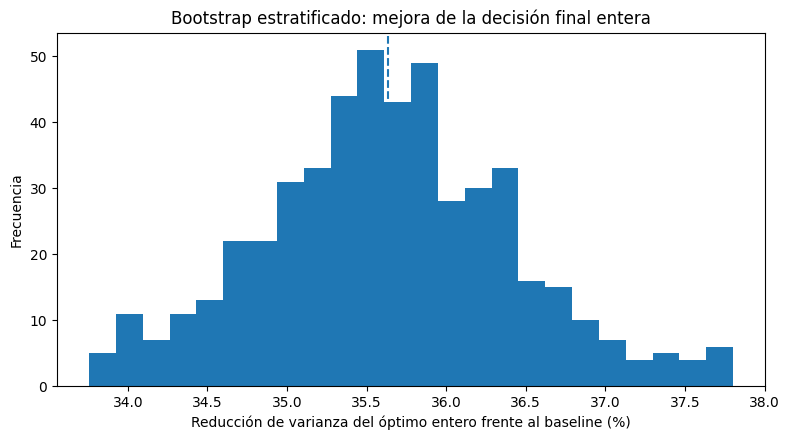

INTERPRETACIÓN BOOTSTRAP: la reducción media de varianza del óptimo entero fue 35.63% (IC95% percentil: 34.04% a 37.38%).
El costo medio de integralidad fue 0.0041% (IC95%: 0.0015% a 0.0074%).
Proporción de réplicas en las que la decisión entera mejora al baseline: 100.0%


In [11]:
def bootstrap_optimizacion(completos, tabla, parametros, B=500, seed=SEED):
    rng_local = np.random.default_rng(seed)
    provincias = parametros["provincias"]
    W = np.asarray(parametros["W"], dtype=float)

    grupos = {
        p: completos.loc[completos["provincia"] == p, "RN"].to_numpy(dtype=float)
        for p in provincias
    }

    reduccion_var = np.empty(B)
    reduccion_se = np.empty(B)
    gap_integralidad = np.empty(B)
    asignaciones = np.empty((B, len(provincias)), dtype=int)
    obj_baseline = np.empty(B)
    obj_opt_int = np.empty(B)
    obj_opt_rel = np.empty(B)

    for b in range(B):
        S_b = np.empty(len(provincias))

        for j, p in enumerate(provincias):
            vals = grupos[p]
            muestra = rng_local.choice(vals, size=len(vals), replace=True)
            S_b[j] = np.std(muestra, ddof=1)

        par_b = parametros.copy()
        par_b["S"] = S_b
        par_b["a"] = (W ** 2) * (S_b ** 2)

        sol_rel_b = resolver_neyman_acotada(None, par_b)
        sol_int_b = resolver_entero_exacto(par_b)

        off_b = objetivo_varianza(parametros["n_oficial"], par_b)
        rel_b = sol_rel_b["objetivo"]
        int_b = sol_int_b["objetivo"]

        obj_baseline[b] = off_b
        obj_opt_rel[b] = rel_b
        obj_opt_int[b] = int_b

        reduccion_var[b] = (off_b - int_b) / off_b
        reduccion_se[b] = (np.sqrt(off_b) - np.sqrt(int_b)) / np.sqrt(off_b)
        gap_integralidad[b] = (int_b - rel_b) / rel_b
        asignaciones[b, :] = sol_int_b["x"]

    return {
        "reduccion_var": reduccion_var,
        "reduccion_se": reduccion_se,
        "gap_integralidad": gap_integralidad,
        "asignaciones": asignaciones,
        "obj_baseline": obj_baseline,
        "obj_opt_rel": obj_opt_rel,
        "obj_opt_int": obj_opt_int,
    }


BOOT_B = 500
boot = bootstrap_optimizacion(completos, tabla, parametros, B=BOOT_B)

resumen_boot = pd.DataFrame({
    "Métrica": [
        "Reducción relativa de varianza (óptimo entero)",
        "Reducción relativa de error estándar (óptimo entero)",
        "Costo relativo de integralidad",
    ],
    "Media": [
        boot["reduccion_var"].mean(),
        boot["reduccion_se"].mean(),
        boot["gap_integralidad"].mean(),
    ],
    "IC95_inf": [
        np.quantile(boot["reduccion_var"], 0.025),
        np.quantile(boot["reduccion_se"], 0.025),
        np.quantile(boot["gap_integralidad"], 0.025),
    ],
    "Mediana": [
        np.quantile(boot["reduccion_var"], 0.50),
        np.quantile(boot["reduccion_se"], 0.50),
        np.quantile(boot["gap_integralidad"], 0.50),
    ],
    "IC95_sup": [
        np.quantile(boot["reduccion_var"], 0.975),
        np.quantile(boot["reduccion_se"], 0.975),
        np.quantile(boot["gap_integralidad"], 0.975),
    ],
})
display(resumen_boot)

prob_mejora = np.mean(boot["reduccion_var"] > 0)
print("P(reducción de varianza entera > 0) =", prob_mejora)

ic_alloc = pd.DataFrame({
    "provincia": parametros["provincias"],
    "p2.5": np.quantile(boot["asignaciones"], 0.025, axis=0),
    "mediana": np.quantile(boot["asignaciones"], 0.50, axis=0),
    "p97.5": np.quantile(boot["asignaciones"], 0.975, axis=0),
})
ic_alloc["amplitud_ic"] = ic_alloc["p97.5"] - ic_alloc["p2.5"]
display(ic_alloc.sort_values("mediana", ascending=False).round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(100 * boot["reduccion_var"], bins=24)
ax.axvline(100 * boot["reduccion_var"].mean(), linestyle="--", linewidth=1.5)
ax.set_xlabel("Reducción de varianza del óptimo entero frente al baseline (%)")
ax.set_ylabel("Frecuencia")
ax.set_title("Bootstrap estratificado: mejora de la decisión final entera")
plt.tight_layout()
plt.show()

ci_var = np.quantile(boot["reduccion_var"], [0.025, 0.975])
ci_int = np.quantile(boot["gap_integralidad"], [0.025, 0.975])

print(
    "INTERPRETACIÓN BOOTSTRAP: la reducción media de varianza del óptimo entero fue "
    f"{100*boot['reduccion_var'].mean():.2f}% "
    f"(IC95% percentil: {100*ci_var[0]:.2f}% a {100*ci_var[1]:.2f}%)."
)
print(
    "El costo medio de integralidad fue "
    f"{100*boot['gap_integralidad'].mean():.4f}% "
    f"(IC95%: {100*ci_int[0]:.4f}% a {100*ci_int[1]:.4f}%)."
)
print(
    "Proporción de réplicas en las que la decisión entera mejora al baseline:",
    f"{100*np.mean(boot['reduccion_var'] > 0):.1f}%"
)

### Significancia práctica

La validación no se limita a comprobar que el objetivo es menor en una sola muestra. El intervalo bootstrap cuantifica cuánto puede variar la mejora cuando cambia la estimación de las desviaciones provinciales.

También se obtienen intervalos para cada $n_h^\star$, lo que permite distinguir:

- Provincias con recomendación estable
- Provincias cuya asignación es sensible a la incertidumbre de $S_h$.

# 14. Complejidad teórica y escalabilidad empírica — Criterio 6

## 14.1 Relajación CVXPY

La formulación cónica tiene dimensión proporcional a $H$. Como referencia algebraica densa para un método interior de punto, el sistema KKT puede requerir:

$$
O(H^3)
$$

por iteración, aunque la dispersidad y la estructura real pueden reducir el costo práctico.

## 14.2 Neyman acotada / KKT

Cada evaluación de $\nu$ requiere $O(H)$ y la bisección:

$$
O\!\left(\log\frac{1}{\varepsilon}\right)
$$

iteraciones. Por tanto:

$$
O\!\left(
H\log\frac{1}{\varepsilon}
\right).
$$

## 14.3 Problema entero exacto

Sea:

$$
R=T-\sum_h\ell_h
$$

el número de unidades que deben añadirse después de satisfacer la cobertura mínima.

Con una cola de prioridad, la implementación usada requiere aproximadamente:

$$
O(H + R\log H).
$$

Este algoritmo es exacto para la estructura separable del proyecto y produce la decisión final entera.

## 14.4 Evaluación empírica

Se miden tiempos para al menos cuatro tamaños del problema y se comparan CVXPY, Neyman/KKT y el algoritmo entero exacto. Las instancias sintéticas se usan únicamente para estudiar escalabilidad; las conclusiones agrícolas se basan en las 21 provincias reales.

,H,CVXPY_media_s,CVXPY_std_s,Neyman_KKT_media_s,Neyman_KKT_std_s,Entero_exacto_media_s,Entero_exacto_std_s,cond_Hessiano
0,25,0.012133,0.000291,0.000670,0.000044,0.005678,0.001593,1901.084756
1,100,0.019488,0.003821,0.000819,0.000015,0.016882,0.000606,4819.173438
2,400,0.039435,0.000842,0.001046,0.000027,0.068717,0.002324,3729.062672
3,1000,0.107719,0.002538,0.001420,0.000028,0.311433,0.007323,4615.500968


Pendiente empírica log-log aproximada (CVXPY): 0.5695207076452227
Pendiente empírica log-log aproximada (entero exacto): 1.062593694941084


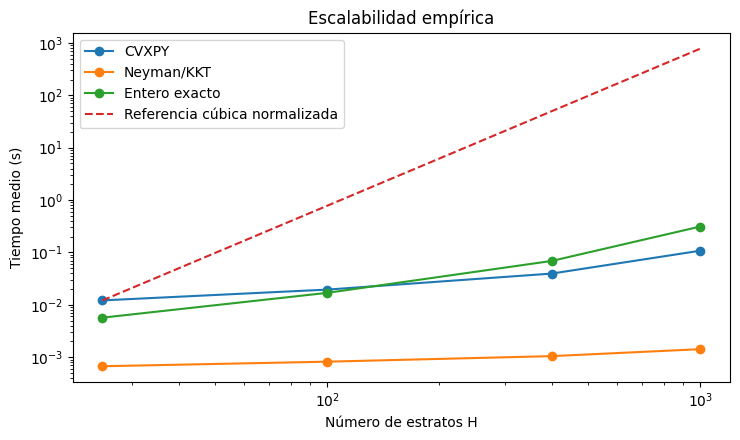

In [12]:
def generar_instancia_sintetica(H, parametros_base, seed):
    rng_local = np.random.default_rng(seed)
    idx = rng_local.choice(len(parametros_base["a"]), size=H, replace=True)

    N0 = np.asarray(parametros_base["N"])[idx]
    S0 = np.asarray(parametros_base["S"])[idx]

    N_syn = np.maximum(50.0, N0 * rng_local.uniform(0.8, 1.2, size=H))
    S_syn = np.maximum(1e-4, S0 * rng_local.uniform(0.9, 1.1, size=H))
    W_syn = N_syn / N_syn.sum()
    a_syn = (W_syn ** 2) * (S_syn ** 2)

    T_por_estrato = parametros_base["T"] / len(parametros_base["a"])
    T_syn = float(round(T_por_estrato * H))
    lower_syn = np.full(H, float(N_MIN_BASE))
    upper_syn = N_syn.copy()

    if lower_syn.sum() >= T_syn:
        T_syn = lower_syn.sum() + H

    return {
        "provincias": np.array([f"E{i+1}" for i in range(H)]),
        "N": N_syn,
        "W": W_syn,
        "S": S_syn,
        "a": a_syn,
        "T": T_syn,
        "lower": lower_syn,
        "upper": upper_syn,
        "n_oficial": None,
    }


def medir_tiempo(funcion, *args, repeticiones=2, **kwargs):
    tiempos = []
    for _ in range(repeticiones):
        t0 = time.perf_counter()
        funcion(*args, **kwargs)
        tiempos.append(time.perf_counter() - t0)
    return {
        "media": float(np.mean(tiempos)),
        "std": float(np.std(tiempos, ddof=1)) if len(tiempos) > 1 else 0.0,
        "tiempos": tiempos,
    }


tamanos = [25, 100, 400, 1000]

# Warm-up del solver convexo.
_ = resolver_modelo(None, generar_instancia_sintetica(10, parametros, SEED + 999))

filas_tiempo = []

for H_syn in tamanos:
    par_syn = generar_instancia_sintetica(H_syn, parametros, SEED + H_syn)

    tiempo_cvx = medir_tiempo(resolver_modelo, None, par_syn, repeticiones=3)
    tiempo_neyman = medir_tiempo(
        resolver_neyman_acotada, None, par_syn, repeticiones=5
    )
    tiempo_entero = medir_tiempo(
        resolver_entero_exacto, par_syn, repeticiones=5
    )

    sol_syn = resolver_neyman_acotada(None, par_syn)
    hdiag_syn = 2.0 * par_syn["a"] / (sol_syn["x"] ** 3)
    cond_syn = float(np.max(hdiag_syn) / np.min(hdiag_syn))

    filas_tiempo.append({
        "H": H_syn,
        "CVXPY_media_s": tiempo_cvx["media"],
        "CVXPY_std_s": tiempo_cvx["std"],
        "Neyman_KKT_media_s": tiempo_neyman["media"],
        "Neyman_KKT_std_s": tiempo_neyman["std"],
        "Entero_exacto_media_s": tiempo_entero["media"],
        "Entero_exacto_std_s": tiempo_entero["std"],
        "cond_Hessiano": cond_syn,
    })

escalabilidad = pd.DataFrame(filas_tiempo)
display(escalabilidad)

pendiente_cvx = np.polyfit(
    np.log(escalabilidad["H"]),
    np.log(escalabilidad["CVXPY_media_s"]),
    1
)[0]

pendiente_entera = np.polyfit(
    np.log(escalabilidad["H"]),
    np.log(escalabilidad["Entero_exacto_media_s"]),
    1
)[0]

print("Pendiente empírica log-log aproximada (CVXPY):", pendiente_cvx)
print("Pendiente empírica log-log aproximada (entero exacto):", pendiente_entera)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(escalabilidad["H"], escalabilidad["CVXPY_media_s"], marker="o", label="CVXPY")
ax.loglog(escalabilidad["H"], escalabilidad["Neyman_KKT_media_s"], marker="o", label="Neyman/KKT")
ax.loglog(escalabilidad["H"], escalabilidad["Entero_exacto_media_s"], marker="o", label="Entero exacto")
ref_cubica = escalabilidad["CVXPY_media_s"].iloc[0] * (
    escalabilidad["H"] / escalabilidad["H"].iloc[0]
) ** 3
ax.loglog(escalabilidad["H"], ref_cubica, linestyle="--", label="Referencia cúbica normalizada")
ax.set_xlabel("Número de estratos H")
ax.set_ylabel("Tiempo medio (s)")
ax.set_title("Escalabilidad empírica")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretación de escalabilidad

La complejidad $O(H^3)$ se presenta como referencia densa por iteración de un método interior aplicado al sistema KKT; no se espera que los tiempos reales reproduzcan exactamente una ley cúbica, porque CVXPY y CLARABEL explotan estructura dispersa y además existe un costo casi fijo de canonicalización e inicialización.

En la ejecución final se utilizaron $H=25,100,400,1000$. La pendiente empírica log--log fue aproximadamente:

$$
0.543 \quad \text{para CVXPY},
$$

mientras que para el algoritmo entero exacto fue aproximadamente:

$$
0.961.
$$

La pendiente de CVXPY es menor que 3 en el rango ensayado, lo cual es compatible con que la referencia $O(H^3)$ sea una cota algebraica densa y con que, en estas instancias, tengan un papel importante la dispersidad y los costos fijos del solver.

Para el algoritmo entero exacto, una pendiente cercana a 1 es coherente con su estructura:

$$
O(H+R\log H),
$$

cuando el número de unidades adicionales $R$ crece aproximadamente de forma proporcional a $H$ en las instancias sintéticas.

La solución Neyman/KKT explota la separabilidad específica del modelo y tiene costo aproximado:

$$
O\!\left(H\log\frac{1}{\varepsilon}\right),
$$

por lo que resulta especialmente eficiente como verificación analítica.

Las instancias sintéticas se utilizan únicamente para estudiar complejidad computacional. Las conclusiones agrícolas se basan en las 21 provincias reales. El condicionamiento sintético observado se mantuvo aproximadamente entre $1.9\times10^3$ y $4.8\times10^3$, por lo que se discute conjuntamente con el Hessiano y el sistema KKT del problema real.

# 15. Condicionamiento y estabilidad numérica — Criterio 6

La matriz local relevante es el Hessiano:

$$
H(\mathbf n^\star)
=
\operatorname{diag}
\left(
\frac{2a_h}{(n_h^\star)^3}
\right).
$$

Se reportan:

1. Número de condición del Hessiano completo
2. Número de condición sobre variables libres
3. Condición del sistema KKT reducido
4. Efecto de la escala numérica aplicada al objetivo

El número de condición se interpreta como sensibilidad algebraica local, no como sustituto del bootstrap.

In [13]:
x_star = np.asarray(sol_verif["x"], dtype=float)
a = np.asarray(parametros["a"], dtype=float)
lower = np.asarray(parametros["lower"], dtype=float)
upper = np.asarray(parametros["upper"], dtype=float)

hdiag = 2.0 * a / (x_star ** 3)
Hess = np.diag(hdiag)
cond_hess = np.linalg.cond(Hess)

libres = (x_star > lower + 1e-7) & (x_star < upper - 1e-7)

if libres.sum() >= 2:
    H_free = np.diag(hdiag[libres])
    cond_hess_free = np.linalg.cond(H_free)

    Aeq = np.ones((1, libres.sum()))
    KKT_raw = np.block([
        [H_free, Aeq.T],
        [Aeq, np.zeros((1, 1))]
    ])
    KKT_scaled = np.block([
        [OBJ_SCALE * H_free, Aeq.T],
        [Aeq, np.zeros((1, 1))]
    ])

    cond_kkt_raw = np.linalg.cond(KKT_raw)
    cond_kkt_scaled = np.linalg.cond(KKT_scaled)
else:
    cond_hess_free = np.nan
    cond_kkt_raw = np.nan
    cond_kkt_scaled = np.nan

condicionamiento = pd.DataFrame({
    "Matriz": [
        "Hessiano completo",
        "Hessiano variables libres",
        "KKT reducido sin escala",
        f"KKT reducido con escala x{OBJ_SCALE:.0e}",
    ],
    "Número_condición": [
        cond_hess,
        cond_hess_free,
        cond_kkt_raw,
        cond_kkt_scaled,
    ]
})

display(condicionamiento)
print("Autovalor mínimo Hessiano:", np.min(hdiag))
print("Autovalor máximo Hessiano:", np.max(hdiag))
print("Variables libres:", int(libres.sum()), "de", len(x_star))

,Matriz,Número_condición
0,Hessiano completo,2.112169e+03
1,Hessiano variables libres,1.849434e+01
2,KKT reducido sin escala,5.461225e+09
3,KKT reducido con escala x1e+06,5.464726e+03


Autovalor mínimo Hessiano: 4.9259384491862245e-12
Autovalor máximo Hessiano: 1.0404415215654309e-08
Variables libres: 11 de 21


### Interpretación del condicionamiento

El Hessiano completo puede presentar un número de condición elevado porque los estratos tienen pesos, desviaciones y tamaños óptimos muy distintos. Sin embargo, varias variables quedan fijadas en la cota inferior; por ello el Hessiano restringido a las variables libres representa mejor la curvatura efectiva alrededor del óptimo.

El sistema KKT sin escala puede estar mucho peor condicionado que el Hessiano. Multiplicar el objetivo por `OBJ_SCALE` no cambia la solución, pero mejora el balance numérico entre la curvatura del objetivo y la restricción de suma. Esta afirmación se contrasta numéricamente reportando ambos números de condición.

La estabilidad final no se juzga solo por $\kappa$: también se verifica que CVXPY y KKT coincidan, que el gap primal-dual sea cercano a cero y que las restricciones se satisfagan dentro de tolerancia.


# 16. Sensibilidad y escenarios — Criterio 7

Se desarrollan tres análisis adicionales sobre la decisión final entera:

1. Tamaño total $T$
2. Cobertura mínima $n_{\min}$
3. Variabilidad histórica $S_h^{2024}$ frente a $S_h^{2025}$

En cada escenario se reporta:

- Varianza y error estándar
- Cambio en la decisión entera
- Distancia $L_1$ frente al escenario base
- Máximo cambio provincial
- Provincia más afectada

La relajación se conserva para KKT/duales, pero la sensibilidad operativa se interpreta con números enteros de UPA.

,T,Varianza_entera,Error_estándar_entero,Cotas_inferiores_activas,Máxima_asignación,L1_cambio_participaciones,Max_cambio_UPA,Provincia_max_cambio
0,800,0.000057,0.007577,11,168,0.033619,32,MANABÍ
1,938,0.000048,0.006936,10,200,0.000000,0,AZUAY
2,1100,0.000040,0.006359,10,239,0.028839,39,MANABÍ
3,1300,0.000034,0.005813,9,286,0.052301,86,MANABÍ


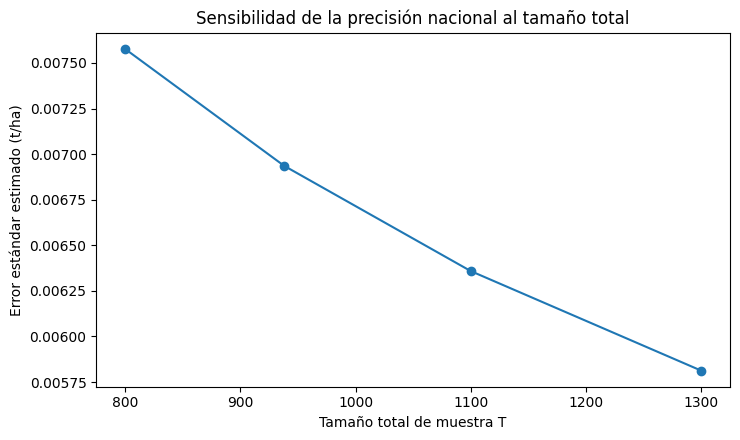

,Regla,Varianza_entera,Error_estándar_entero,Reducción_var_vs_baseline_%,Estratos_en_cota,L1_cambio_decisión,Max_cambio_UPA,Provincia_max_cambio
0,mínimo uniforme 5,0.000046,0.006800,37.752484,9,74,9,MANABÍ
1,mínimo uniforme 9,0.000048,0.006936,35.241909,10,0,0,AZUAY
2,mínimo uniforme 15,0.000052,0.007198,30.261176,14,138,17,MANABÍ
3,mínimo uniforme 20,0.000056,0.007509,24.106591,14,278,35,MANABÍ
4,mínimo uniforme 25,0.000063,0.007910,15.781392,15,418,53,MANABÍ
5,cota por precisión provincial,0.000049,0.007017,33.713329,10,76,20,IMBABURA


,provincia,n_oficial,n_requerido_con_S2025,baseline_cumple
0,AZUAY,46,7,True
1,BOLÍVAR,51,7,True
2,CAÑAR,21,8,True
3,CARCHI,24,15,True
4,CHIMBORAZO,17,11,True
5,COTOPAXI,13,6,True
6,EL ORO,53,18,True
7,ESMERALDAS,110,58,True
8,GUAYAS,80,51,True
9,IMBABURA,9,29,False


,Escenario,Varianza_baseline,Varianza_óptima_entera,Reducción_%,Error_estándar_entero,L1_cambio_decisión,Max_cambio_UPA,Provincia_max_cambio
0,Variabilidad histórica S_2024,0.000147,0.000101,31.252062,0.010058,140,49,LOS RÍOS
1,Variabilidad observada S_2025,0.000074,0.000048,35.241909,0.006936,0,0,AZUAY



RESUMEN DE INFLUENCIA SOBRE LA DECISIÓN ENTERA
Regla de cobertura con mayor cambio L1: mínimo uniforme 25 | cambio L1 = 418 | provincia más afectada = MANABÍ
Escenario de variabilidad con mayor cambio L1: Variabilidad histórica S_2024 | cambio L1 = 140 | provincia más afectada = LOS RÍOS


In [14]:
# ============================================================
# Sensibilidad 1: tamaño total de muestra — decisión entera
# ============================================================
T_vals = [800, 938, 1100, 1300]
filas_T = []
asignaciones_T = {}

x_base_entero = sol_entera["x"].astype(int)

for T_val in T_vals:
    par = parametros.copy()
    par["T"] = float(T_val)

    sol = resolver_entero_exacto(par)
    asignaciones_T[T_val] = sol["x"]

    share_base = x_base_entero / parametros["T"]
    share_scn = sol["x"] / T_val

    # Para T distintos, se comparan también participaciones.
    cambio = sol["x"] - x_base_entero
    jmax = int(np.argmax(np.abs(cambio)))

    filas_T.append({
        "T": T_val,
        "Varianza_entera": sol["objetivo"],
        "Error_estándar_entero": sol["error_estandar"],
        "Cotas_inferiores_activas": int(
            np.sum(sol["x"] == np.ceil(par["lower"]).astype(int))
        ),
        "Máxima_asignación": int(sol["x"].max()),
        "L1_cambio_participaciones": float(np.sum(np.abs(share_scn - share_base))),
        "Max_cambio_UPA": int(np.max(np.abs(cambio))),
        "Provincia_max_cambio": parametros["provincias"][jmax],
    })

sens_T = pd.DataFrame(filas_T)
display(sens_T)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sens_T["T"], sens_T["Error_estándar_entero"], marker="o")
ax.set_xlabel("Tamaño total de muestra T")
ax.set_ylabel("Error estándar estimado (t/ha)")
ax.set_title("Sensibilidad de la precisión nacional al tamaño total")
plt.tight_layout()
plt.show()

# ============================================================
# Sensibilidad 2: cobertura mínima uniforme — decisión entera
# ============================================================
filas_min = []

for m in [5, 9, 15, 20, 25]:
    par = parametros.copy()
    par["lower"] = np.full(len(tabla), float(m))

    sol = resolver_entero_exacto(par)
    cambio = sol["x"] - x_base_entero
    jmax = int(np.argmax(np.abs(cambio)))

    filas_min.append({
        "Regla": f"mínimo uniforme {m}",
        "Varianza_entera": sol["objetivo"],
        "Error_estándar_entero": sol["error_estandar"],
        "Reducción_var_vs_baseline_%":
            100 * (baseline["objetivo"] - sol["objetivo"]) / baseline["objetivo"],
        "Estratos_en_cota": int(
            np.sum(sol["x"] == np.ceil(par["lower"]).astype(int))
        ),
        "L1_cambio_decisión": int(np.sum(np.abs(cambio))),
        "Max_cambio_UPA": int(np.max(np.abs(cambio))),
        "Provincia_max_cambio": parametros["provincias"][jmax],
    })

# Escenario con requerimientos de precisión provincial inspirados
# en los niveles de confianza/error del diseño 2025.
z_h = norm.ppf((1.0 + tabla["nivel_confianza"].to_numpy(dtype=float)) / 2.0)
e_h = tabla["error_muestral"].to_numpy(dtype=float)
N_h = tabla["N_h"].to_numpy(dtype=float)
S_h = tabla["S_2025"].to_numpy(dtype=float)

n_req = (
    (z_h**2) * N_h * (S_h**2)
    /
    ((e_h**2) * (N_h - 1.0) + (z_h**2) * (S_h**2))
)
lower_precision = np.maximum(1.0, np.ceil(n_req))

par_precision = parametros.copy()
par_precision["lower"] = lower_precision
sol_precision = resolver_entero_exacto(par_precision)

cambio_precision = sol_precision["x"] - x_base_entero
jmax_precision = int(np.argmax(np.abs(cambio_precision)))

filas_min.append({
    "Regla": "cota por precisión provincial",
    "Varianza_entera": sol_precision["objetivo"],
    "Error_estándar_entero": sol_precision["error_estandar"],
    "Reducción_var_vs_baseline_%":
        100 * (baseline["objetivo"] - sol_precision["objetivo"]) / baseline["objetivo"],
    "Estratos_en_cota": int(
        np.sum(sol_precision["x"] == np.ceil(lower_precision).astype(int))
    ),
    "L1_cambio_decisión": int(np.sum(np.abs(cambio_precision))),
    "Max_cambio_UPA": int(np.max(np.abs(cambio_precision))),
    "Provincia_max_cambio": parametros["provincias"][jmax_precision],
})

sens_cobertura = pd.DataFrame(filas_min)
display(sens_cobertura)

tabla_precision = tabla[["provincia", "n_oficial"]].copy()
tabla_precision["n_requerido_con_S2025"] = lower_precision.astype(int)
tabla_precision["baseline_cumple"] = (
    tabla_precision["n_oficial"] >= tabla_precision["n_requerido_con_S2025"]
)
display(tabla_precision)

# ============================================================
# Sensibilidad 3: S_2024 vs S_2025 — decisión entera
# ============================================================
escenarios_S = []

for etiqueta, S_scn in [
    ("Variabilidad histórica S_2024", tabla["S_2024"].to_numpy(dtype=float)),
    ("Variabilidad observada S_2025", tabla["S_2025"].to_numpy(dtype=float)),
]:
    par = parametros.copy()
    par["S"] = S_scn
    par["a"] = (parametros["W"] ** 2) * (S_scn ** 2)

    sol = resolver_entero_exacto(par)
    obj_off = objetivo_varianza(parametros["n_oficial"], par)

    cambio = sol["x"] - x_base_entero
    jmax = int(np.argmax(np.abs(cambio)))

    escenarios_S.append({
        "Escenario": etiqueta,
        "Varianza_baseline": obj_off,
        "Varianza_óptima_entera": sol["objetivo"],
        "Reducción_%": 100 * (obj_off - sol["objetivo"]) / obj_off,
        "Error_estándar_entero": sol["error_estandar"],
        "L1_cambio_decisión": int(np.sum(np.abs(cambio))),
        "Max_cambio_UPA": int(np.max(np.abs(cambio))),
        "Provincia_max_cambio": parametros["provincias"][jmax],
    })

sens_S_df = pd.DataFrame(escenarios_S)
display(sens_S_df)

# Resumen explícito de influencia.
cobertura_sin_base = sens_cobertura.loc[
    sens_cobertura["Regla"] != f"mínimo uniforme {N_MIN_BASE}"
].copy()

fila_cov = cobertura_sin_base.loc[
    cobertura_sin_base["L1_cambio_decisión"].idxmax()
]
fila_S = sens_S_df.loc[
    sens_S_df["L1_cambio_decisión"].idxmax()
]

print("\nRESUMEN DE INFLUENCIA SOBRE LA DECISIÓN ENTERA")
print(
    "Regla de cobertura con mayor cambio L1:",
    fila_cov["Regla"],
    "| cambio L1 =", int(fila_cov["L1_cambio_decisión"]),
    "| provincia más afectada =", fila_cov["Provincia_max_cambio"]
)
print(
    "Escenario de variabilidad con mayor cambio L1:",
    fila_S["Escenario"],
    "| cambio L1 =", int(fila_S["L1_cambio_decisión"]),
    "| provincia más afectada =", fila_S["Provincia_max_cambio"]
)

### Lectura aplicada de la sensibilidad

La sensibilidad se interpreta sobre $\mathbf n_{\mathbb Z}^\star$, porque esa es la decisión implementable.

- **Tamaño total $T$:** al aumentar la muestra disminuye el error estándar con rendimientos marginales decrecientes y cambian las participaciones provinciales.
- **Cobertura mínima $n_{\min}$:** endurecerla protege provincias pequeñas, pero reduce la libertad para minimizar la varianza nacional.
- **Variabilidad $S_h$:** determina junto con $W_h$ dónde es más valiosa una UPA adicional.
- **$S_h^{2024}$ vs. $S_h^{2025}$:** esta comparación es especialmente importante porque muestra la diferencia entre una aproximación potencialmente disponible ex ante y el benchmark retrospectivo ex post.
- **Cota de precisión provincial:** aproxima un objetivo institucional donde no basta la precisión nacional.

El bloque `RESUMEN DE INFLUENCIA` identifica qué escenario modifica más la decisión entera.

# 17. Diagnóstico numérico

Se reportan por separado evidencias de la relajación y de la decisión final:

### Relajación convexa
- `status` y solver
- Factibilidad
- CVXPY vs. Neyman acotada
- Residuos KKT
- Gap primal--dual
- Duales y precio sombra
- Condicionamiento

### Problema entero
- Suma exacta de 938
- Verificación de integralidad
- Gap de integralidad frente a la cota relajada
- Costo del redondeo balanceado
- Comparación con Differential Evolution entero

In [15]:
diagnostico = pd.DataFrame({
    "Métrica": [
        "Solver relajación",
        "Status relajación",
        "Objetivo relajado",
        "Objetivo entero final",
        "Violación máxima relajación",
        "Violación máxima entero",
        "Δx CVXPY vs Neyman acotada",
        "Δf CVXPY vs Neyman acotada",
        "Residuo estacionariedad KKT",
        "Complementariedad KKT",
        "Gap primal-dual relajación",
        "Condición Hessiano",
        "Condición Hessiano libre",
        "Gap integralidad (%)",
        "Costo redondeo vs óptimo entero (%)",
        "Gap mejor DE entero vs óptimo entero (%)",
        "Suma n_h entero",
        "Todos los n_h son enteros",
        "Tolerancias solver",
        "Advertencias solver",
        "Máx. diferencia dual CVXPY-KKT",
    ],
    "Valor": [
        sol_principal["solver"],
        sol_principal["status"],
        sol_principal["objetivo"],
        sol_entera["objetivo"],
        sol_principal["factibilidad"]["violacion_max"],
        sol_entera["factibilidad"]["violacion_max"],
        delta_x,
        delta_f,
        kkt["estacionariedad_inf"],
        kkt["complementariedad"],
        kkt["gap_primal_dual"],
        cond_hess,
        cond_hess_free,
        100 * gap_int_rel,
        100 * gap_redondeo_vs_entero,
        gap_heu,
        int(sol_entera["x"].sum()),
        bool(np.all(sol_entera["x"] == np.round(sol_entera["x"]))),
        str(sol_principal["tolerancias"]),
        "; ".join(sol_principal["advertencias"]) if sol_principal["advertencias"] else "Ninguna",
        comparacion_duales["diferencia_abs"].max(),
    ]
})
display(diagnostico)

,Métrica,Valor
0,Solver relajación,CLARABEL
1,Status relajación,optimal
2,Objetivo relajado,0.000048
3,Objetivo entero final,0.000048
4,Violación máxima relajación,0.0
5,Violación máxima entero,0.0
6,Δx CVXPY vs Neyman acotada,0.005898
7,Δf CVXPY vs Neyman acotada,0.0
8,Residuo estacionariedad KKT,0.0
9,Complementariedad KKT,0.0


# 18. Resultados e interpretación aplicada

La tabla integra:

- Población provincial
- Variabilidad 2025
- Asignación oficial
- Muestra ejecutada
- Neyman clásica
- Óptimo de la relajación
- Óptimo entero final

La comparación principal conserva:

$$
T=938.
$$

## Síntesis de evidencias

- **Baseline:** asignación oficial planificada con 938 UPA.
- **Relajación:** CVXPY y Neyman acotada; sirve como cota inferior y para KKT/duales.
- **Decisión final:** óptimo entero exacto.
- **Heurística:** Differential Evolution sobre asignaciones enteras.
- **Validación:** bootstrap del óptimo entero.
- **Sensibilidad:** $T$, $n_{\min}$ y $S_h$, evaluados sobre decisiones enteras.

### ¿Qué decisión cambiaría en la práctica?

Si la prioridad fuera minimizar el error nacional, se usaría la asignación entera optimizada como benchmark para redistribuir las 938 UPA. Si también se exige precisión mínima provincial, se debe aplicar el escenario con cotas de precisión antes de adoptar la distribución definitiva.

La solución basada en $S_h^{2025}$ debe interpretarse retrospectivamente; para planificar un operativo futuro se utilizaría una estimación de variabilidad disponible ex ante.

,provincia,N_h,n_oficial,n_ejecutado,n_obs,S_2024,S_2025,n_neyman_clasica,n_opt_relajado,n_opt_entero_final,cambio_entero_vs_oficial
11,MANABÍ,47308,100,101,101,0.31,0.2270,217.63,200.59,200,100
10,LOS RÍOS,45270,127,127,127,0.35,0.1834,168.19,155.01,155,28
7,ESMERALDAS,35598,110,110,110,0.32,0.2316,167.04,153.96,154,44
8,GUAYAS,31056,80,83,83,0.27,0.2170,136.53,125.83,126,46
14,ORELLANA,16698,35,37,37,0.25,0.2379,80.49,74.19,74,39
19,SUCUMBÍOS,15576,37,38,38,0.26,0.2078,65.58,60.44,60,23
18,SANTO DOMINGO DE LOS TSÁCHILAS,9180,20,21,21,0.19,0.1609,29.93,27.59,28,8
13,NAPO,5187,34,36,33,0.28,0.1547,16.25,14.98,15,-19
16,PICHINCHA,4407,35,36,36,0.29,0.1525,13.62,12.55,13,-22
6,EL ORO,3164,53,54,53,0.36,0.2032,13.03,12.01,12,-41


,Indicador,Valor
0,Varianza baseline oficial,0.000074
1,Varianza relajada (cota inferior),0.000048
2,Varianza óptima entera FINAL,0.000048
3,Reducción varianza relajada vs baseline (%),35.244130
4,Reducción varianza entera vs baseline (%),35.241909
5,Reducción error estándar entera vs baseline (%),19.527588
6,Costo de integralidad (%),0.003431
7,Costo adicional del redondeo balanceado vs ent...,0.159194


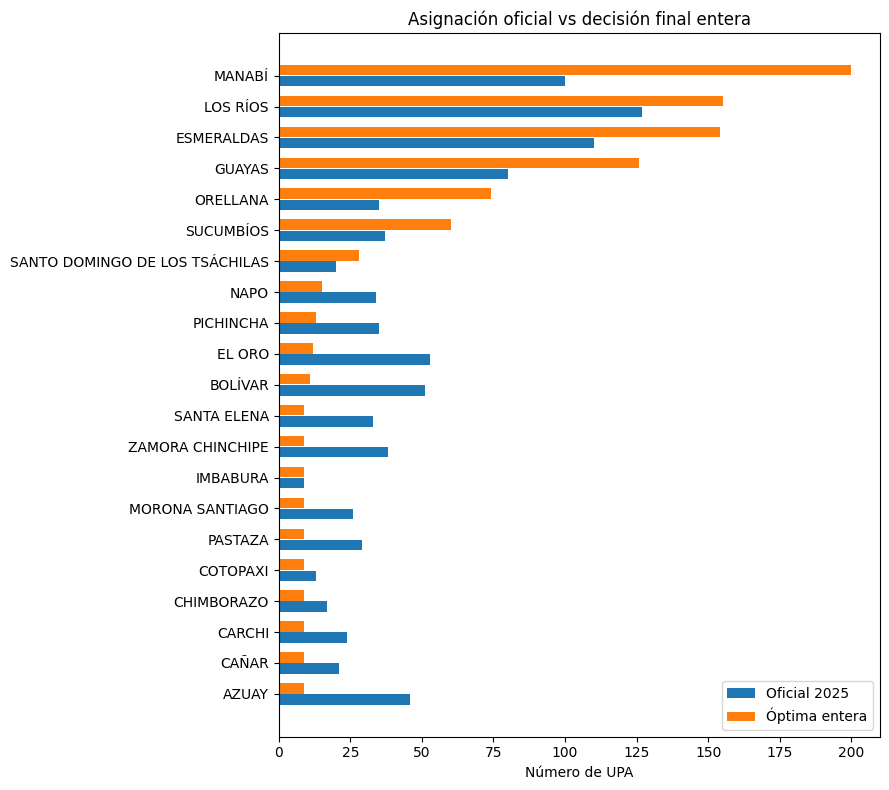

In [16]:
tabla_resultados = tabla[
    ["provincia", "N_h", "n_oficial", "n_ejecutado", "n_obs", "S_2024", "S_2025"]
].copy()

tabla_resultados["n_neyman_clasica"] = neyman_clasica["x"]
tabla_resultados["n_opt_relajado"] = sol_verif["x"]
tabla_resultados["n_opt_entero_final"] = sol_entera["x"]
tabla_resultados["cambio_entero_vs_oficial"] = (
    tabla_resultados["n_opt_entero_final"] - tabla_resultados["n_oficial"]
)

display(
    tabla_resultados
    .sort_values("n_opt_entero_final", ascending=False)
    .round({
        "S_2024": 4,
        "S_2025": 4,
        "n_neyman_clasica": 2,
        "n_opt_relajado": 2,
    })
)

mejora_var_rel = (
    (baseline["objetivo"] - sol_verif["objetivo"])
    / baseline["objetivo"]
)
mejora_var_ent = (
    (baseline["objetivo"] - sol_entera["objetivo"])
    / baseline["objetivo"]
)

mejora_se_rel = (
    (baseline["error_estandar"] - sol_verif["error_estandar"])
    / baseline["error_estandar"]
)
mejora_se_ent = (
    (baseline["error_estandar"] - sol_entera["error_estandar"])
    / baseline["error_estandar"]
)

resumen_principal = pd.DataFrame({
    "Indicador": [
        "Varianza baseline oficial",
        "Varianza relajada (cota inferior)",
        "Varianza óptima entera FINAL",
        "Reducción varianza relajada vs baseline (%)",
        "Reducción varianza entera vs baseline (%)",
        "Reducción error estándar entera vs baseline (%)",
        "Costo de integralidad (%)",
        "Costo adicional del redondeo balanceado vs entero (%)",
    ],
    "Valor": [
        baseline["objetivo"],
        sol_verif["objetivo"],
        sol_entera["objetivo"],
        100 * mejora_var_rel,
        100 * mejora_var_ent,
        100 * mejora_se_ent,
        100 * gap_int_rel,
        100 * gap_redondeo_vs_entero,
    ]
})
display(resumen_principal)

# Gráfico: asignación oficial vs decisión final entera
plot_df = tabla_resultados.sort_values("n_opt_entero_final", ascending=True)

y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(y - 0.18, plot_df["n_oficial"], height=0.34, label="Oficial 2025")
ax.barh(y + 0.18, plot_df["n_opt_entero_final"], height=0.34, label="Óptima entera")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["provincia"])
ax.set_xlabel("Número de UPA")
ax.set_title("Asignación oficial vs decisión final entera")
ax.legend()
plt.tight_layout()
plt.show()

## 18.1 Interpretación aplicada de los resultados

La regla de Neyman muestra que, en el interior de las restricciones:

$$
n_h^\star\propto W_hS_h.
$$

Por ello una provincia tiende a recibir más muestra cuando combina:

- Mayor peso poblacional
- Mayor variabilidad del rendimiento

La asignación entera final conserva esa lógica, pero además debe cumplir el total exacto de 938 y las cotas provinciales.

La comparación debe distinguir tres niveles:

1. **Neyman clásica:** referencia analítica sin cotas.
2. **Relajación acotada:** solución continua para convexidad, KKT y dualidad.
3. **Óptimo entero:** decisión final implementable.

El diseño oficial 2025 persiguió también representatividad provincial mediante niveles de confianza y errores diferenciados. Por eso minimizar la varianza nacional no equivale automáticamente a diseñar la mejor muestra para publicar resultados de cada provincia.

In [17]:
# Interpretación automática de cambios de la decisión final entera
top_aumentos = (
    tabla_resultados.nlargest(6, "cambio_entero_vs_oficial")
    [["provincia", "n_oficial", "n_opt_entero_final", "cambio_entero_vs_oficial"]]
)
top_reducciones = (
    tabla_resultados.nsmallest(6, "cambio_entero_vs_oficial")
    [["provincia", "n_oficial", "n_opt_entero_final", "cambio_entero_vs_oficial"]]
)

print("Mayores aumentos recomendados (decisión entera):")
display(top_aumentos)

print("Mayores reducciones recomendadas (decisión entera):")
display(top_reducciones)

print(
    f"Con T={T}, la decisión ENTERA reduce la varianza estimada "
    f"{100*mejora_var_ent:.2f}% y el error estándar "
    f"{100*mejora_se_ent:.2f}% frente al baseline oficial."
)

print(
    f"El costo de exigir integralidad respecto a la cota continua es "
    f"{100*gap_int_rel:.4f}%."
)

Mayores aumentos recomendados (decisión entera):


,provincia,n_oficial,n_opt_entero_final,cambio_entero_vs_oficial
11,MANABÍ,100,200,100
8,GUAYAS,80,126,46
7,ESMERALDAS,110,154,44
14,ORELLANA,35,74,39
10,LOS RÍOS,127,155,28
19,SUCUMBÍOS,37,60,23


Mayores reducciones recomendadas (decisión entera):


,provincia,n_oficial,n_opt_entero_final,cambio_entero_vs_oficial
6,EL ORO,53,12,-41
1,BOLÍVAR,51,11,-40
0,AZUAY,46,9,-37
20,ZAMORA CHINCHIPE,38,9,-29
17,SANTA ELENA,33,9,-24
16,PICHINCHA,35,13,-22


Con T=938, la decisión ENTERA reduce la varianza estimada 35.24% y el error estándar 19.53% frente al baseline oficial.
El costo de exigir integralidad respecto a la cota continua es 0.0034%.


# 19. Limitaciones

1. El objetivo principal minimiza la varianza nacional y no garantiza por sí solo precisión provincial.

2. $N_h$ se considera conocido y fijo. Si el marco cambia, cambian $W_h$ y la asignación.  

3. $S_h^{2025}$ es retrospectivo y No estaba disponible al planificar el mismo operativo 2025.  

4. El proyecto mantiene 938 como esfuerzo comparable aunque la base final tenga 962 registros; la causa de esa diferencia no está documentada en los insumos utilizados

5. Se supone costo homogéneo por UPA. Si los costos de campo difieren por provincia, una restricción de tamaño no equivale exactamente a una restricción presupuestaria.  

6. KKT y dualidad corresponden a la relajación continua; la decisión final se valida separadamente como entera.

7. No se modelan no respuesta ni logística.

8. El análisis es ex post. No demuestra que la asignación optimizada hubiera producido exactamente los mismos resultados observados.

# 20. Conclusiones

1. El proyecto integra formulación matemática, optimización, verificación y análisis estadístico dentro de un problema real de diseño muestral agrícola.

2. La decisión final es una asignación entera de 938 UPA. La relajación continua es estrictamente convexa y fue resuelta con CVXPY/CLARABEL; la solución fue corroborada mediante Neyman acotada/KKT, con diferencias numéricas prácticamente nulas y gap primal--dual de $3.388\times10^{-20}$. El costo de pasar de la relajación al óptimo entero es solamente 0,0034\%.

3. Frente al baseline oficial, la asignación entera reduce la varianza estimada en 35,24\% y el error estándar en 19,53\%. El bootstrap de 500 réplicas confirmó que la mejora es estable, con un IC95\% de 34,04\% a 37,38\% para la reducción de varianza. Differential Evolution fue factible pero menos eficiente, con un mejor gap de 8,24\% y tiempos de cómputo sustancialmente mayores.

4. La sensibilidad mostró que $T$, $n_{\min}$ y $S_h$ modifican de manera material la decisión. En particular, elevar la cobertura mínima reduce la ganancia nacional, evidenciando el compromiso entre eficiencia global y precisión territorial.

### Recomendación

Utilizar la asignación entera optimizada como benchmark de eficiencia nacional y, antes de una implementación institucional, seleccionar explícitamente las restricciones de precisión provincial y actualizar los parámetros de variabilidad con información disponible antes del levantamiento.